In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [4]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [5]:
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1000GeV.shape: (267452, 53)
X_SLQ_1100GeV.shape: (271062, 53)
X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)


## Signal VLQ

In [6]:
masses_VLQ = [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1500GeV.shape: (293700, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [7]:
Lum = 300

In [8]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_136TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-136TeV.txt'

xsec_data_136TeV = np.loadtxt(xsec_file_136TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_136TeV = xsec_data_136TeV[:,0].astype(int)
fidxsec_SLQ_136TeV = dict(zip(masses_136TeV, xsec_data_136TeV[:,1]*k_LQ))
fidxsec_VLQ_136TeV = dict(zip(masses_136TeV, xsec_data_136TeV[:,2]*k_LQ))


masses_SLQ_136TeV = [1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_136TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_136TeV = [fidxsec_SLQ_136TeV[ii] for ii in masses_SLQ_136TeV]
fidxsec_VLQ_non0_136TeV = [fidxsec_VLQ_136TeV[ii] for ii in masses_VLQ_136TeV]


#  interpolate
f_xsec_SLQ_log_136TeV = interp1d(masses_SLQ_136TeV, np.log10(fidxsec_SLQ_non0_136TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_136TeV = interp1d(masses_VLQ_136TeV, np.log10(fidxsec_VLQ_non0_136TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_136TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-136TeV-betas.txt'

xsec_data_betas_136TeV = np.loadtxt(xsec_file_betas_136TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_136TeV[:,0]
ratio_mean_136TeV = xsec_data_betas_136TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_136TeV = interp1d(betas, ratio_mean_136TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_136TeV = interp1d(betas, ratio_mean_136TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_136TeV(mass, beta):
    return 10**f_xsec_SLQ_log_136TeV(mass) * f_ratio_SLQ_log_136TeV(beta)

def fid_xsec_VLQ_136TeV(mass, beta):
    return 10**f_xsec_VLQ_log_136TeV(mass) * f_ratio_VLQ_log_136TeV(beta)

In [9]:
masses = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

beta = 0.5

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_136TeV(masses, beta)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_136TeV(masses, beta)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.1858593690398773 [fb]
0.1919005476833441 [fb]


In [10]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1000 GeV: 267452   fid_xsec =  0.6083961314217237 [fb]
# eventos SLQ 1100 GeV: 271062   fid_xsec =  0.3362679305439991 [fb]
# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.1858593690398773 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.1027267304497876 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.05677831149119609 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.03274082226527356 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.018879769659449087 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.010825167537574591 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.006206868745239666 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.0036272936607113187 [fb]
 
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.5876780098947455 [fb]
# eventos VLQ 1500 GeV: 293700   fid_xsec =  0.3358209820131246 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.1919005476833441 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.1112967851203237 [fb]
# eventos VLQ 1800 GeV

In [11]:
# # FOR 13 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.19136
# k_tt = 1.2593273872014419
# crossfid_tt = (5.1373984*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.39648 * 3.440676833094312,
#               'singletP2': 0.283008 * 3.440676833094312,
#               'Wbbjets': 0.9988452079186325 * 0.9781509289273502,
#               'ttW': 0.0231785208 * 3.056401327463198,
#               'ttZ': 0.050087088 * 3.056401327463198,
#               'ttH': 0.025004896 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [12]:
# FOR 13.6 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.222944
k_tt = 1.2593273872014419
crossfid_tt = (6.70014736*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.5381712 * 3.440676833094312,
              'singletP2': 0.30416544 * 3.440676833094312,
              'Wbbjets': 1.3920832941861587 * 0.9781509289273502,
              'ttW': 0.03137058432 * 3.056401327463198,
              'ttZ': 0.06296147519999999 * 3.056401327463198,
              'ttH': 0.0317827504 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  8.68409975158515 [fb]
# eventos singletP1: 179677   fid_xsec =  1.8516731800785655 [fb]
# eventos singletP2: 94219   fid_xsec =  1.046534982835938 [fb]
# eventos Wbbjets: 162448   fid_xsec =  1.361667567352437 [fb]
# eventos ttW: 141919   fid_xsec =  0.09588109555894418 [fb]
# eventos ttZ: 16178   fid_xsec =  0.1924355363803212 [fb]
# eventos ttH: 12068   fid_xsec =  0.07032710808880543 [fb]


In [13]:
# # FOR 14 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.244
# k_tt = 1.2593273872014419
# crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.632632 * 3.440676833094312,
#               'singletP2': 0.3182704 * 3.440676833094312,
#               'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
#               'ttW': 0.03683196 * 3.056401327463198,
#               'ttZ': 0.0715444 * 3.056401327463198,
#               'ttH': 0.03630132 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [14]:
# MAX SM dataset
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])


weigth_gen_SM = {}

for ch_it in fidxsec_SM:

    print(f"fraction of {ch_it}:", fidxsec_SM[ch_it] / totalcrossSM )

    weigth_gen_SM[ch_it] = len(X_B_all[ch_it]) / (fidxsec_SM[ch_it] / totalcrossSM)

print('\nchannel limiting the SM background: ', min(weigth_gen_SM, key=weigth_gen_SM.get) , '\n')


max_evs_SM = {}

for ch_it in fidxsec_SM:
    max_evs_SM[ch_it] = round( min(weigth_gen_SM.values()) * (fidxsec_SM[ch_it] / totalcrossSM) )
    print(f"# eventos {ch_it} (max):", max_evs_SM[ch_it])

max_SM_dataset = sum(max_evs_SM.values())
print('\nmax SM dataset length: ', max_SM_dataset )

fraction of tt: 0.6528112702272598
fraction of singletP1: 0.1391961349260401
fraction of singletP2: 0.0786713477534256
fraction of Wbbjets: 0.10236086177019672
fraction of ttW: 0.007207685491082754
fraction of ttZ: 0.014465988477201772
fraction of ttH: 0.005286711354793298

channel limiting the SM background:  ttZ 

# eventos tt (max): 730070
# eventos singletP1 (max): 155670
# eventos singletP2 (max): 87982
# eventos Wbbjets (max): 114475
# eventos ttW (max): 8061
# eventos ttZ (max): 16178
# eventos ttH (max): 5912

max SM dataset length:  1118348


In [15]:
masses_VLQ

[1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

## Number of events to get a balanced dataset

In [16]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ]


max_SM_dataset = min(750000, max_SM_dataset)

num_data_NP = min(int(max_SM_dataset / (len(masses_SLQ) + len(masses_VLQ))) , min(num_data_SLQ + num_data_VLQ) )

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction * (len(masses_SLQ) + len(masses_VLQ)) )

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP * (len(masses_SLQ) + len(masses_VLQ)) - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])



print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 37500

BACKGROUND events chosen (weighted by xsec):
# tt: 489608
# singletP1: 104397
# singletP2: 59004
# Wbbjets: 76771
# ttW: 5406
# ttZ: 10849
# ttH: 3965
# total B events chosen:  750000


In [17]:
# keep just the events needed

for m_it in masses_SLQ:
    X_SLQ_all[m_it] = X_SLQ_all[m_it][:num_data_NP]
    df_SLQ_all[m_it] = df_SLQ_all[m_it][:num_data_NP]

print(" ")
for m_it in masses_VLQ:
    X_VLQ_all[m_it] = X_VLQ_all[m_it][:num_data_NP]
    df_VLQ_all[m_it] = df_VLQ_all[m_it][:num_data_NP]

print("")
for ch_it in fidxsec_SM:
    X_B_all[ch_it] = X_B_all[ch_it][:num_data_SM_dict[ch_it]]
    df_B_all[ch_it] = df_B_all[ch_it][:num_data_SM_dict[ch_it]]

In [18]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)

for ch_it in fidxsec_SM:
    print(f" channel {ch_it}:", "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]", " B_exp_ch: ", round(Lum * fidxsec_SM[ch_it]) )


S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  3991
 channel tt:   fid_xsec =  8.68409975158515 [fb]  B_exp_ch:  2605
 channel singletP1:   fid_xsec =  1.8516731800785655 [fb]  B_exp_ch:  556
 channel singletP2:   fid_xsec =  1.046534982835938 [fb]  B_exp_ch:  314
 channel Wbbjets:   fid_xsec =  1.361667567352437 [fb]  B_exp_ch:  409
 channel ttW:   fid_xsec =  0.09588109555894418 [fb]  B_exp_ch:  29
 channel ttZ:   fid_xsec =  0.1924355363803212 [fb]  B_exp_ch:  58
 channel ttH:   fid_xsec =  0.07032710808880543 [fb]  B_exp_ch:  21

masses:            [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_expected (SLQ):  [183, 101, 56, 31, 17, 10, 6, 3, 2, 1]

masses:            [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [176, 101, 58, 33, 19, 12, 7, 4, 3, 2]


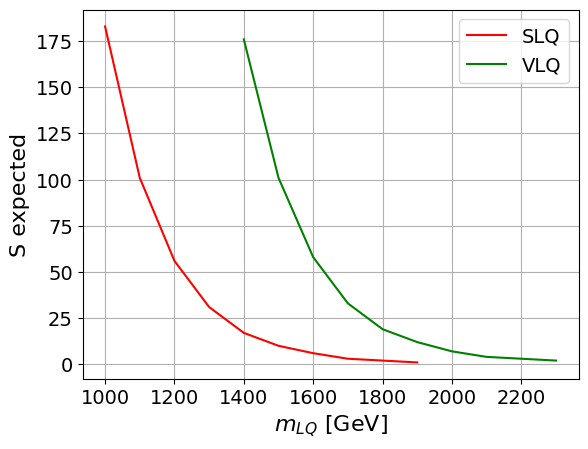

In [19]:
plt.plot(masses_SLQ, S_expected_SLQ, color='red', label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, color='green', label='VLQ')
# plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

In [20]:
matched_VLQ_masses = []

for s_ev in S_expected_SLQ:
    # buscamos la VLQ que tenga la menor diferencia de eventos
    idx_match = np.argmin([abs(vlq_ev - s_ev) for vlq_ev in S_expected_VLQ])
    matched_mass = masses_VLQ[idx_match]
    matched_VLQ_masses.append(matched_mass)

# Mostrar resultados
for slq, s_ev, vlq, v_ev in zip(masses_SLQ, S_expected_SLQ, matched_VLQ_masses,
                                 [S_expected_VLQ[masses_VLQ.index(m)] for m in matched_VLQ_masses]):
    print(f"SLQ {slq} GeV ({s_ev} ev)  -> VLQ {vlq} GeV ({v_ev} ev)")

SLQ 1000 GeV (183 ev)  -> VLQ 1400 GeV (176 ev)
SLQ 1100 GeV (101 ev)  -> VLQ 1500 GeV (101 ev)
SLQ 1200 GeV (56 ev)  -> VLQ 1600 GeV (58 ev)
SLQ 1300 GeV (31 ev)  -> VLQ 1700 GeV (33 ev)
SLQ 1400 GeV (17 ev)  -> VLQ 1800 GeV (19 ev)
SLQ 1500 GeV (10 ev)  -> VLQ 1900 GeV (12 ev)
SLQ 1600 GeV (6 ev)  -> VLQ 2000 GeV (7 ev)
SLQ 1700 GeV (3 ev)  -> VLQ 2200 GeV (3 ev)
SLQ 1800 GeV (2 ev)  -> VLQ 2300 GeV (2 ev)
SLQ 1900 GeV (1 ev)  -> VLQ 2300 GeV (2 ev)


### Plot

In [21]:
def plot_variable(var_name_aux, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    var_name = feats_label.index(var_name_aux)

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'darkorange', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'm($LQ_3^S$)={m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'm($LQ_3^V$)={m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][:int(len(SM_data['tt'])*fidxsec_SM['tt']/totalcrossSM),var_name],
        np.concatenate([SM_data['singletP1'][:int(len(SM_data['singletP1'])*fidxsec_SM['singletP1']/totalcrossSM),var_name], SM_data['singletP2'][:int(len(SM_data['singletP2'])*fidxsec_SM['singletP2']/totalcrossSM),var_name]]),
        SM_data['Wbbjets'][:int(len(SM_data['Wbbjets'])*fidxsec_SM['Wbbjets']/totalcrossSM),var_name],
        np.concatenate([SM_data['ttW'][:int(len(SM_data['ttW'])*fidxsec_SM['ttW']/totalcrossSM),var_name], SM_data['ttZ'][:int(len(SM_data['ttZ'])*fidxsec_SM['ttZ']/totalcrossSM),var_name], SM_data['ttH'][:int(len(SM_data['ttH'])*fidxsec_SM['ttH']/totalcrossSM),var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=[r'$t\bar{t}$',r'single $t$',r'W+j',r'fake $t\bar{t}$, $t\bar{t}V$, $t\bar{t}H$'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{feats_label[var_name]} [GeV]", fontsize=14)
    # plt.xlabel(r"$E_T^{miss}$ [GeV]", fontsize=14)
    plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$H_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m_T(E_T^{miss},\tau)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
    # plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)

    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)
        # plt.ylim(1e-2,1e-0)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10, loc='upper right')
    plt.show()

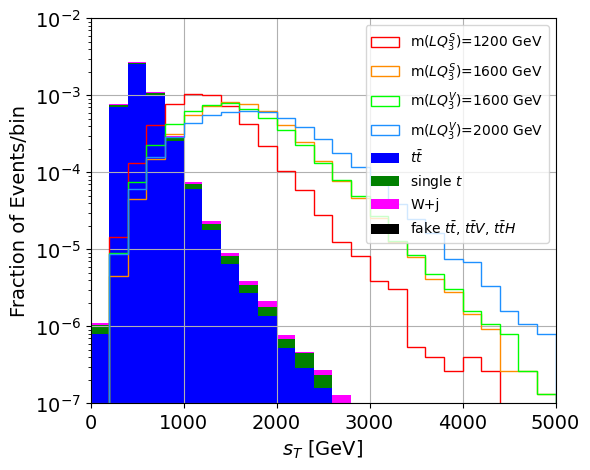

In [22]:
# Ejemple: sT
plot_variable('sT', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25,
            #   range=[20,2500] # MET
              range=[0,5000] # sT and HT and mT-METtau and m-b1b2
            #   range=[0.4,4.9] # dR-b1b2
              )

# 1. DATA FORMAT for CLASSIFIERS

In [23]:
# to save memory
del X_SLQ_all
del X_VLQ_all
del X_B_all

In [24]:
# DATA WITH UNCERTAINTIES

factor_down = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_down = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_down.columns:
    df_B_all_down["sT"] = df_B_all_down["sT"] * (1 - factor_down)



df_SLQ_all_down = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_SLQ_all_down[key] = df_sample



df_VLQ_all_down = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_VLQ_all_down[key] = df_sample

In [25]:
# DATA WITH UNCERTAINTIES

factor_up = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_up = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_up.columns:
    df_B_all_up["sT"] = df_B_all_up["sT"] * (1 + factor_up)



df_SLQ_all_up = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_SLQ_all_up[key] = df_sample



df_VLQ_all_up = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_VLQ_all_up[key] = df_sample

In [26]:
# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_SM = pd.concat(df_B_all.values(), ignore_index=True)
del df_B_all

df_all = pd.concat([df_SM] + list(df_SLQ_all.values()) + list(df_VLQ_all.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
joblib.dump(scaler, mainfolder + 'saved-models/scaler_features_136TeV.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all[mass]), columns=df_SLQ_all[mass].columns) for mass in df_SLQ_all}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all[mass]), columns=df_VLQ_all[mass].columns) for mass in df_VLQ_all}






# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.10, pseudo_ratio=0.25):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (300000, 53)
X_val_SM :  (75000, 53)
X_test_SM :  (187500, 53)
X_pseudo_SM :  (187500, 53)

X_train_SLQ1200 :  (15000, 53)
X_val_SLQ1200 :  (3750, 53)
X_test_SLQ1200 :  (9375, 53)
X_pseudo_SLQ1200 :  (9375, 53)

X_train_VLQ1600 :  (15000, 53)
X_val_VLQ1600 :  (3750, 53)
X_test_VLQ1600 :  (9375, 53)
X_pseudo_VLQ1600 :  (9375, 53)


In [27]:
# to save memory
del df_SM
del df_SLQ_all
del df_VLQ_all

In [28]:

# Apply normalization
df_SM_down_norm = pd.DataFrame(scaler.transform(df_B_all_down), columns=df_B_all_down.columns)
df_SLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_down[mass]), columns=df_SLQ_all_down[mass].columns) for mass in df_SLQ_all_down}
df_VLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_down[mass]), columns=df_VLQ_all_down[mass].columns) for mass in df_VLQ_all_down}

# to save memory
del df_B_all_down
del df_SLQ_all_down
del df_VLQ_all_down

In [29]:

# Apply normalization
df_SM_up_norm = pd.DataFrame(scaler.transform(df_B_all_up), columns=df_B_all_up.columns)
df_SLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_up[mass]), columns=df_SLQ_all_up[mass].columns) for mass in df_SLQ_all_up}
df_VLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_up[mass]), columns=df_VLQ_all_up[mass].columns) for mass in df_VLQ_all_up}

# to save memory
del df_B_all_up
del df_SLQ_all_up
del df_VLQ_all_up

# SM vs LQ

In [30]:
# Combine all LQ in a single DataFrame
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# Check, same number of events
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

print(n_SM, n_LQ, n_events)

df_SM_sample = df_SM_norm.sample(n=n_events, random_state=42)
df_LQ_sample = df_LQ_norm.sample(n=n_events, random_state=42)


# Create X, y
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ


def split_class(X, Y, test_ratio=0.25, val_ratio=0.25):

    aux_val_ratio = val_ratio / (1 - test_ratio)

    X_aux, X_test, Y_aux, Y_test = train_test_split(X, Y, test_size=test_ratio, random_state=42, shuffle=True)
    X_train, X_val, Y_train, Y_val = train_test_split(X_aux, Y_aux, test_size=val_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test



# Divide into train, validation and test
X_train, X_val, X_test, y_train, y_val, y_test = split_class(X, y)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

750000 750000 750000
(843750, 53)
(281250, 53)
(375000, 53)


In [31]:
# Combine all LQ in a single DataFrame
df_LQ_down_list = list(df_SLQ_down_norm.values()) + list(df_VLQ_down_norm.values())
df_LQ_down_norm = pd.concat(df_LQ_down_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_down_norm), len(df_LQ_down_norm))


# Create X, y
X_test_down = pd.concat([df_SM_down_norm, df_LQ_down_norm], ignore_index=True)
y_test_down = np.hstack([np.zeros(len(df_SM_down_norm)), np.ones(len(df_LQ_down_norm))])  # 0=SM, 1=LQ


print(X_test_down.shape)
print(y_test_down.shape)

400000 400000
(800000, 53)
(800000,)


In [32]:
# Combine all LQ in a single DataFrame
df_LQ_up_list = list(df_SLQ_up_norm.values()) + list(df_VLQ_up_norm.values())
df_LQ_up_norm = pd.concat(df_LQ_up_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_up_norm), len(df_LQ_up_norm))


# Create X, y
X_test_up = pd.concat([df_SM_up_norm, df_LQ_up_norm], ignore_index=True)
y_test_up = np.hstack([np.zeros(len(df_SM_up_norm)), np.ones(len(df_LQ_up_norm))])  # 0=SM, 1=LQ


print(X_test_up.shape)
print(y_test_up.shape)

400000 400000
(800000, 53)
(800000,)


In [ ]:
# Train
xgb_clf = XGBClassifier(
    n_estimators=1200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=50,
    tree_method='hist'
)

xgb_clf.fit(X_train, y_train,
            eval_set=[(X_train, y_train),
                      (X_val, y_val)],
            verbose=True)

# SAVE
xgb_clf.save_model(mainfolder + "saved-models/modelA_SMLQ_136TeV.json")

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [04:51:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.65020	validation_1-logloss:0.65026
[1]	validation_0-logloss:0.61160	validation_1-logloss:0.61171
[2]	validation_0-logloss:0.57777	validation_1-logloss:0.57792
[3]	validation_0-logloss:0.54515	validation_1-logloss:0.54537
[4]	validation_0-logloss:0.51581	validation_1-logloss:0.51607
[5]	validation_0-logloss:0.48839	validation_1-logloss:0.48868
[6]	validation_0-logloss:0.46297	validation_1-logloss:0.46331
[7]	validation_0-logloss:0.43965	validation_1-logloss:0.44002
[8]	validation_0-logloss:0.41790	validation_1-logloss:0.41830
[9]	validation_0-logloss:0.39844	validation_1-logloss:0.39885
[10]	validation_0-logloss:0.37966	validation_1-logloss:0.38010
[11]	validation_0-logloss:0.36221	validation_1-logloss:0.36269
[12]	validation_0-logloss:0.34599	validation_1-logloss:0.34652
[13]	validation_0-logloss:0.33155	validation_1-logloss:0.33210
[14]	validation_0-logloss:0.31732	validation_1-logloss:0.31789
[15]	validation_0-logloss:0.30399	validation_1-logloss:0.30461
[1

Accuracy: 0.973, ROC-AUC: 0.99653


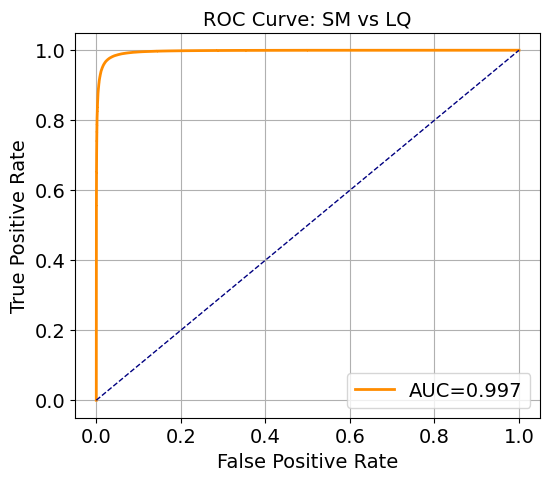

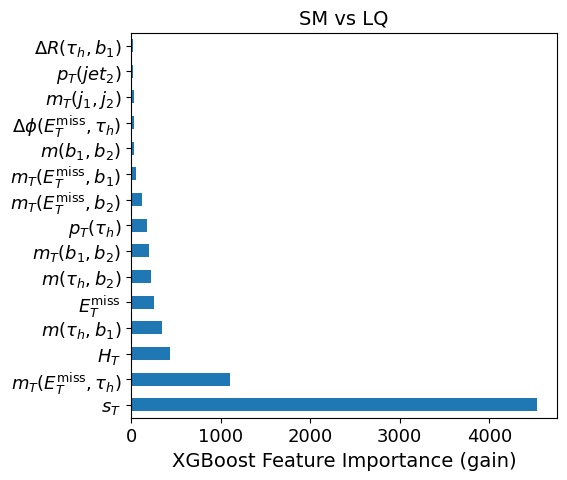

[52, 47, 17, 35, 15, 36, 50, 6, 46, 45, 37, 32, 51, 12, 20]


In [33]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_136TeV.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

Accuracy: 0.976, ROC-AUC: 0.99730
Accuracy: 0.976, ROC-AUC: 0.99728


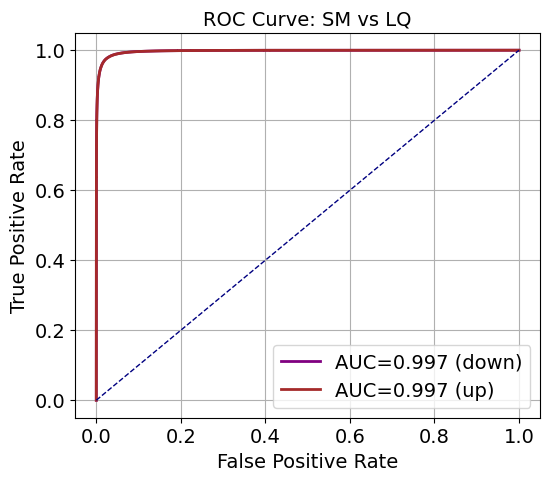

In [34]:

# Evaluate
y_pred_down = xgb_clf.predict(X_test_down)
y_pred_proba_down = xgb_clf.predict_proba(X_test_down)[:,1]

acc_down = accuracy_score(y_test_down, y_pred_down)
auc_down = roc_auc_score(y_test_down, y_pred_proba_down)
print(f"Accuracy: {acc_down:.3f}, ROC-AUC: {auc_down:.5f}")


# Evaluate
y_pred_up = xgb_clf.predict(X_test_up)
y_pred_proba_up = xgb_clf.predict_proba(X_test_up)[:,1]

acc_up = accuracy_score(y_test_up, y_pred_up)
auc_up = roc_auc_score(y_test_up, y_pred_proba_up)
print(f"Accuracy: {acc_up:.3f}, ROC-AUC: {auc_up:.5f}")

# ROC curve
fpr_down, tpr_down, _ = roc_curve(y_test_down, y_pred_proba_down)
fpr_up, tpr_up, _ = roc_curve(y_test_up, y_pred_proba_up)

plt.figure(figsize=(6,5))
plt.plot(fpr_down, tpr_down, color='purple', lw=2, label=f'AUC={auc_down:.3f} (down)')
plt.plot(fpr_up, tpr_up, color='brown', lw=2, label=f'AUC={auc_up:.3f} (up)')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


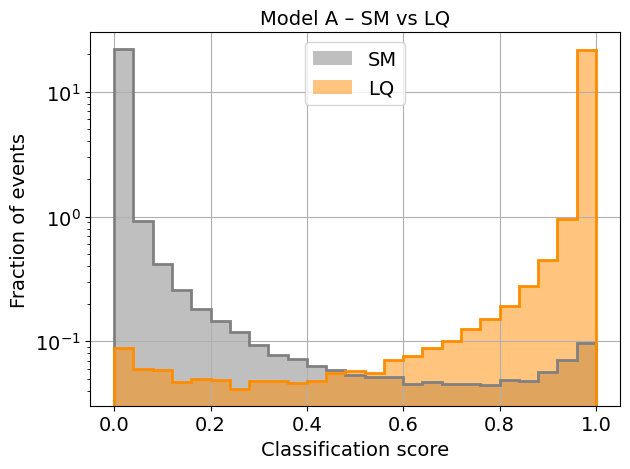

In [35]:

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='darkorange', linewidth=2)

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, color='darkorange', alpha=0.5, label=f'LQ')#\nmean: {np.mean(pred_s):.2f}')

plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
# plt.savefig(mainfolder + 'saved-results/output_classA_multi.pdf', bbox_inches='tight')
plt.show()

# Exclusion and Discovery

In [36]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

for m in masses_SLQ:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm[m] )[:,1]

In [37]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_down = xgb_clf.predict_proba( df_SM_down_norm )[:,1]

scoresA_SLQ_down = {}
scoresA_VLQ_down = {}

for m in masses_SLQ:
    scoresA_SLQ_down[m] = xgb_clf.predict_proba( df_SLQ_down_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ_down[m] = xgb_clf.predict_proba( df_VLQ_down_norm[m] )[:,1]

In [38]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_up = xgb_clf.predict_proba( df_SM_up_norm )[:,1]

scoresA_SLQ_up = {}
scoresA_VLQ_up = {}

for m in masses_SLQ:
    scoresA_SLQ_up[m] = xgb_clf.predict_proba( df_SLQ_up_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ_up[m] = xgb_clf.predict_proba( df_VLQ_up_norm[m] )[:,1]

#### Aux functions

In [39]:
def generate_pseudo_1output_dis(scores_B, scores_S, N_B, N_S):

    sB = np.random.choice(scores_B, N_B, replace=True)
    sS = np.random.choice(scores_S, N_S, replace=True)

    scores = np.concatenate([sB, sS])

    return scores


def generate_pseudo_1output_exc(scores_B, N_B):

    sB = np.random.choice(scores_B, N_B, replace=True)

    return sB




In [40]:
def Z_asimov_dis(S, B):
    return np.sqrt( 2 * np.sum( (S+B) * np.log(1 + S/B) - S ) )


def Z_asimov_exc(S, B):
    return np.sqrt( 2 * np.sum( S - B * np.log(1 + S/B) ) )


def f_mu_hat(mu, N, S, B):

    return sum((ni*si)/(mu*si+bi) - si for ni,si,bi in zip(N,S,B))


def q0(N,S,B,mu_hat):
    """
    this is for discovery
    q0 = −2 log( L(0)/L(μ^) )
    """
    if mu_hat <= 0:
        return 0

    return -2 * sum( ni*np.log((bi)/(mu_hat*si+bi)) - bi + (mu_hat*si+bi) for ni,si,bi in zip(N,S,B)  )


def q1(N,S,B,mu_hat):
    """
    this is for exclusion
    q1 = −2 log( L(1)/L(μ^) )
    """
    if mu_hat > 1:
        return 0
    elif mu_hat > 0:
        return -2 * sum( ni*np.log((si+bi)/(mu_hat*si+bi)) - (1-mu_hat)*si  for ni,si,bi in zip(N,S,B)  )
    else:
        return -2 * sum( ni*np.log((si+bi)/(0.*si+bi)) - (1-0.)*si  for ni,si,bi in zip(N,S,B)  )

## Z-Loop for beta=0.5

B_expected:  3991
S_expected:  183
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  20.61135892696049
Z_asimov_dis_VLQ =  23.254817271922075

Z_asimov_exc_SLQ =  14.554250121883438
Z_asimov_exc_VLQ =  15.786612781180061


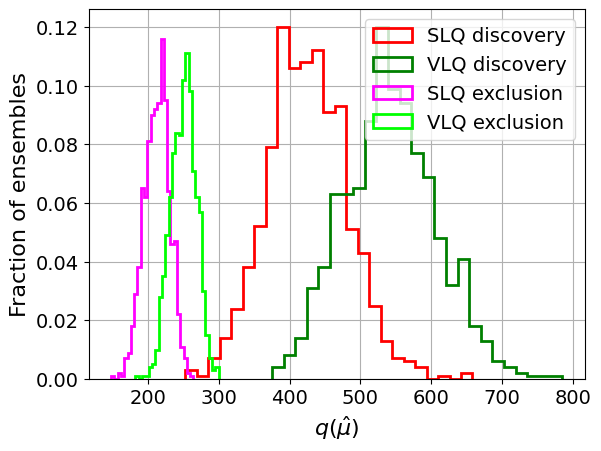


 Binned Likelihood:
Z_dis_SLQ =  20.596731854546153  +-  1.3574110703612599
Z_dis_VLQ =  23.23813761719331  +-  1.3933647022109785

Z_exc_SLQ =  14.611869908377509  +-  0.5987943027170733
Z_exc_VLQ =  15.851633409095777  +-  0.5595912672358484

------------------------------------------

B_expected:  3991
S_expected:  101
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  13.988874653030134
Z_asimov_dis_VLQ =  15.105882346108807

Z_asimov_exc_SLQ =  10.427521607163765
Z_asimov_exc_VLQ =  11.04055661615816


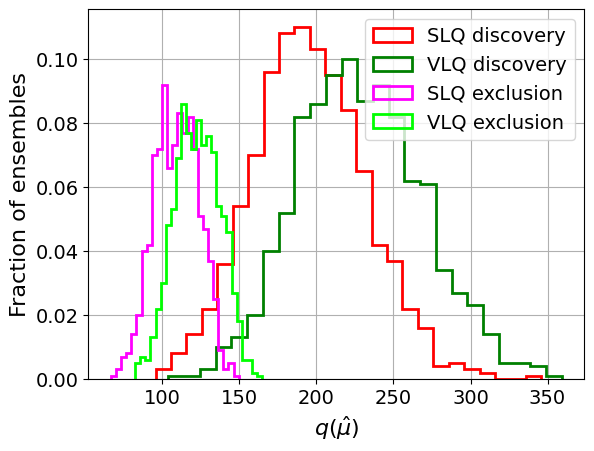


 Binned Likelihood:
Z_dis_SLQ =  13.931859023920849  +-  1.3137376919190773
Z_dis_VLQ =  15.036002520498593  +-  1.3439305998910902

Z_exc_SLQ =  10.45342736199519  +-  0.6850351315368048
Z_exc_VLQ =  11.06304429507167  +-  0.6655622340629584

------------------------------------------

B_expected:  3991
S_expected:  56
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  9.15910266850748
Z_asimov_dis_VLQ =  9.61894242824606

Z_asimov_exc_SLQ =  7.26185590451961
Z_asimov_exc_VLQ =  7.552756526163614


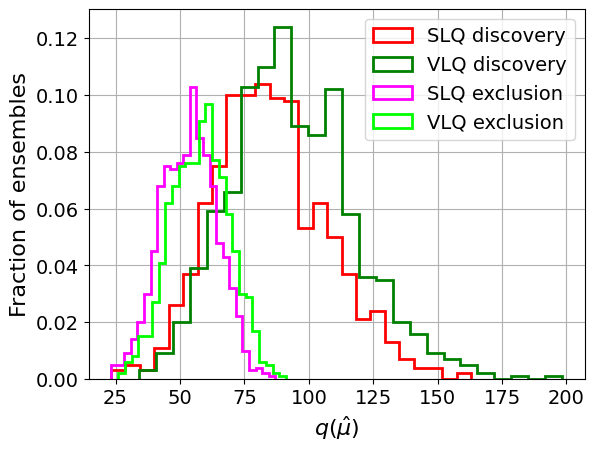


 Binned Likelihood:
Z_dis_SLQ =  9.122397141026896  +-  1.206630611788624
Z_dis_VLQ =  9.560785365625751  +-  1.2465154691542752

Z_exc_SLQ =  7.338603692376865  +-  0.7375340621187414
Z_exc_VLQ =  7.628397703084707  +-  0.7300429829467515

------------------------------------------

B_expected:  3991
S_expected:  31
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.778291464222259
Z_asimov_dis_VLQ =  5.938252647336699

Z_asimov_exc_SLQ =  4.867526391706042
Z_asimov_exc_VLQ =  4.982228764971143


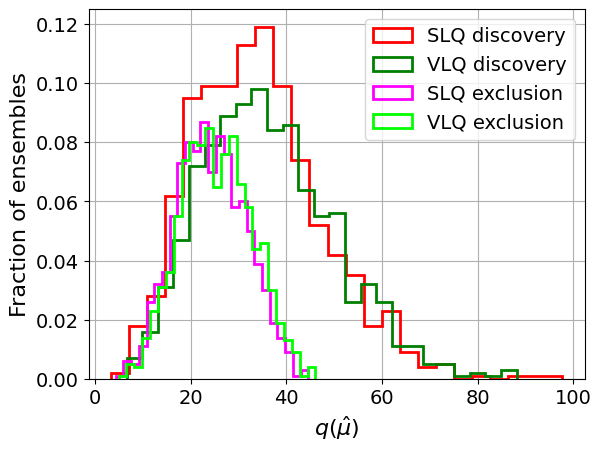


 Binned Likelihood:
Z_dis_SLQ =  5.735219294232274  +-  1.1752596061518696
Z_dis_VLQ =  5.947276634275709  +-  1.1557717383350752

Z_exc_SLQ =  4.888530370971149  +-  0.7407132190369896
Z_exc_VLQ =  4.99177678466857  +-  0.7395046623352751

------------------------------------------

B_expected:  3991
S_expected:  17
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.506245486707994
Z_asimov_dis_VLQ =  3.544979433195132

Z_asimov_exc_SLQ =  3.115727554869973
Z_asimov_exc_VLQ =  3.1463692332058635


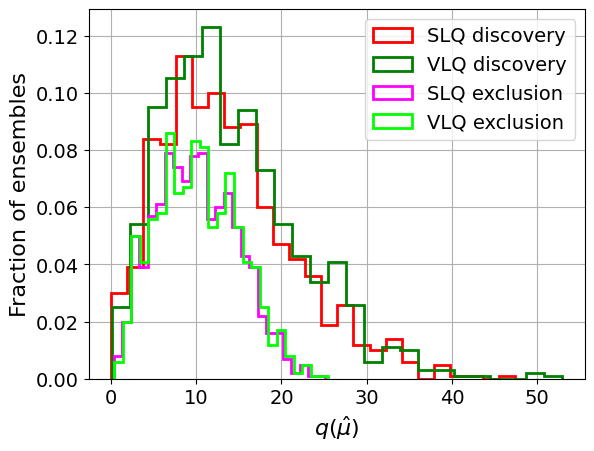


 Binned Likelihood:
Z_dis_SLQ =  3.51103970614045  +-  1.1207586993645733
Z_dis_VLQ =  3.5201770790526132  +-  1.1497302833136538

Z_exc_SLQ =  3.1070914616444  +-  0.7583565569682589
Z_exc_VLQ =  3.1314838814899972  +-  0.7595552071852141

------------------------------------------

B_expected:  3991
S_expected:  10
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.2056358320068217
Z_asimov_dis_VLQ =  2.202596438215682

Z_asimov_exc_SLQ =  2.0345561164302897
Z_asimov_exc_VLQ =  2.0319000424311877


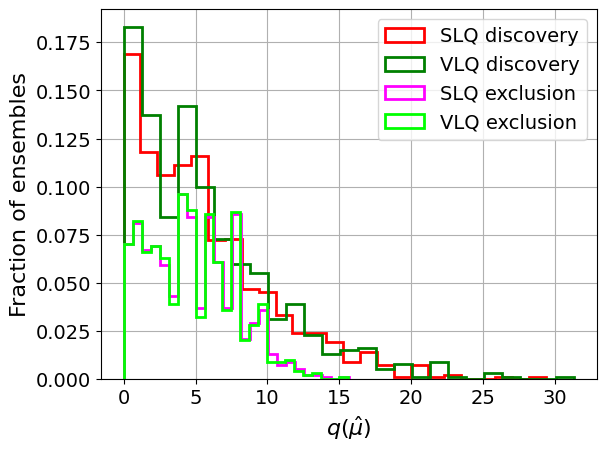


 Binned Likelihood:
Z_dis_SLQ =  2.158805137314002  +-  1.0717816784276617
Z_dis_VLQ =  2.186200973224588  +-  1.130221211724118

Z_exc_SLQ =  2.1548161536189028  +-  0.6935866117444708
Z_exc_VLQ =  2.1554504276523985  +-  0.6922727962785623

------------------------------------------

B_expected:  3991
S_expected:  6
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.3883976757566576
Z_asimov_dis_VLQ =  1.3652154893685604

Z_asimov_exc_SLQ =  1.3155926195064256
Z_asimov_exc_VLQ =  1.2947062142365255


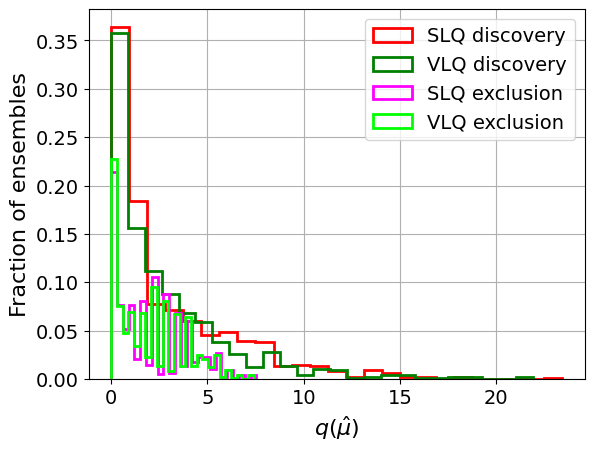


 Binned Likelihood:
Z_dis_SLQ =  1.290782213692883  +-  1.3179699198555261
Z_dis_VLQ =  1.3082699099745163  +-  1.248466325986222

Z_exc_SLQ =  1.2795639233114902  +-  0.6785965090983292
Z_exc_VLQ =  1.2650323783932669  +-  0.6736852720015356

------------------------------------------

B_expected:  3991
S_expected:  3
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.7210725507486295
Z_asimov_dis_VLQ =  0.7029007509898081

Z_asimov_exc_SLQ =  0.7001529458570708
Z_asimov_exc_VLQ =  0.6830026628911289


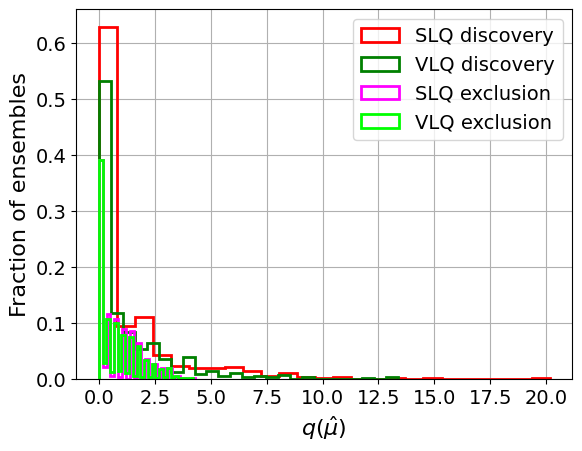


 Binned Likelihood:
Z_dis_SLQ =  0.5772345038935405  +-  1.8389693544558514
Z_dis_VLQ =  0.5845625719846153  +-  1.5893573275965625

Z_exc_SLQ =  0.6511391886789186  +-  0.6910454212464292
Z_exc_VLQ =  0.6358796333331102  +-  0.688042067823121

------------------------------------------

B_expected:  3991
S_expected:  2
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.4886505793751915
Z_asimov_dis_VLQ =  0.47570372105930475

Z_asimov_exc_SLQ =  0.4788155579573788
Z_asimov_exc_VLQ =  0.46637843979808047


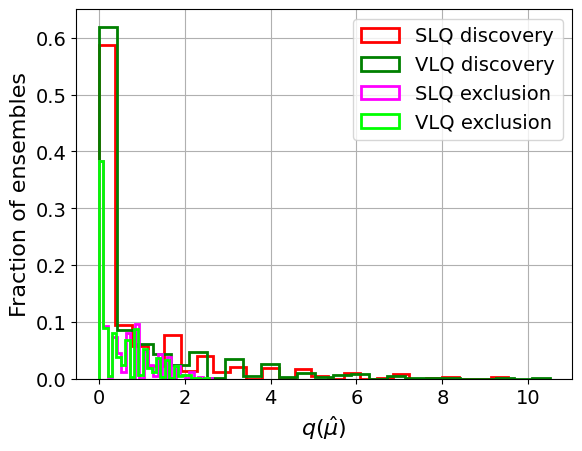


 Binned Likelihood:
Z_dis_SLQ =  0.5307079481123811  +-  1.4521373369245119
Z_dis_VLQ =  0.3427919509402571  +-  2.254379814066397

Z_exc_SLQ =  0.6261795702157894  +-  0.4736675724001757
Z_exc_VLQ =  0.6038936612549447  +-  0.4768091028840554

------------------------------------------

B_expected:  3991
S_expected:  1
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.24844385204039096
Z_asimov_dis_VLQ =  0.23943782223143903

Z_asimov_exc_SLQ =  0.2458374145571931
Z_asimov_exc_VLQ =  0.23701714234939014


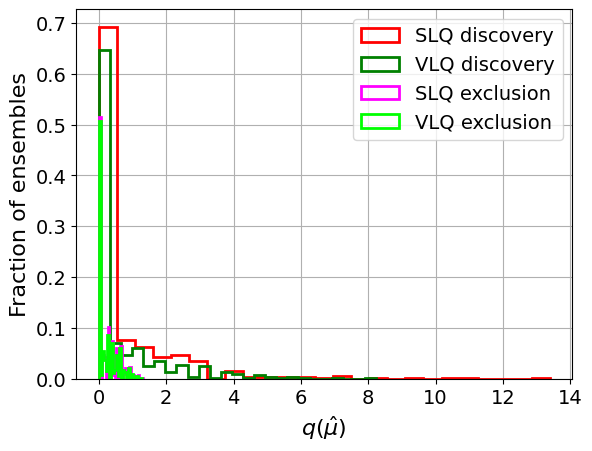


 Binned Likelihood:
Z_dis_SLQ =  0.08639415935300147  +-  8.197380451503282
Z_dis_VLQ =  0.25247854470646325  +-  2.3089407079669146

Z_exc_SLQ =  0.20683023395851435  +-  0.7118901133383404
Z_exc_VLQ =  0.21413388332994737  +-  0.66154662281785

------------------------------------------



In [41]:

S_expected = S_expected_SLQ

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



Z_asimov_dis_SLQ = []
Z_asimov_exc_SLQ = []

Z_asimov_dis_VLQ = []
Z_asimov_exc_VLQ = []


Z_dis_SLQ = []
Z_exc_SLQ = []

Z_dis_VLQ = []
Z_exc_VLQ = []

Z_dis_std_SLQ = []
Z_exc_std_SLQ = []

Z_dis_std_VLQ = []
Z_exc_std_VLQ = []



for m_it in range(len(masses_SLQ)):

    print('B_expected: ', B_expected)
    print('S_expected: ', S_expected[m_it])

    mass_SLQ = masses_SLQ[m_it]
    mass_VLQ = masses_VLQ[m_it]

    print('m_SLQ= ', mass_SLQ, ' GeV' )
    print('m_VLQ= ', mass_VLQ, ' GeV' )

    if S_expected[m_it] == 0:

        Z_asimov_dis_SLQ.append(0)
        Z_asimov_exc_SLQ.append(0)

        Z_asimov_dis_VLQ.append(0)
        Z_asimov_exc_VLQ.append(0)

        Z_dis_SLQ.append(0)
        Z_dis_std_SLQ.append(1)
        Z_exc_SLQ.append(0)
        Z_exc_std_SLQ.append(1)

        Z_dis_VLQ.append(0)
        Z_dis_std_VLQ.append(1)
        Z_exc_VLQ.append(0)
        Z_exc_std_VLQ.append(1)

        continue


    ###################
    # ASIMOV EXPECTED #
    ###################

    # SLQ PDF
    hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
    S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected[m_it])

    # VLQ PDF
    hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
    S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected[m_it])


    Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
    Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

    Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
    Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


    Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
    Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

    Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
    Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


    print('\n Asimov datasets:')
    print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
    print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
    print()
    print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
    print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





    #####################
    # BINNED LIKELIHOOD #
    #####################

    q_dis_SLQ = []
    q_exc_SLQ = []

    q_dis_VLQ = []
    q_exc_VLQ = []


    for pexp_it in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_expected[m_it])


        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        # SLQ
        scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
        N_pseudo_SLQ = hist

        # VLQ
        scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
        N_pseudo_VLQ = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        # SLQ and VLQ (since no signal)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist



        # DISCOVERY (mu_hat=1 idedally)
        # SLQ
        mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
        q_dis_SLQ.append(q_dis_SLQ_it)


        # VLQ
        mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
        q_dis_VLQ.append(q_dis_VLQ_it)



        # EXCLUSION (mu_hat=0 idedally)
        # SLQ
        mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
        q_exc_SLQ.append(q_exc_SLQ_it)


        # VLQ
        mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
        q_exc_VLQ.append(q_exc_VLQ_it)




    # Histogram of q_muhats
    weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
    weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

    weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
    weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
    #plt.xlim(0,1)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$q(\hat{\mu})$",fontsize=16)
    plt.ylabel("Fraction of ensembles",fontsize=16)
    plt.grid()
    plt.legend(fontsize=14)
    plt.show()




    Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
    Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

    Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
    Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


    Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
    Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

    Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
    Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


    Z_dis_SLQ.append(Z_dis_SLQ_it)
    Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
    Z_exc_SLQ.append(Z_exc_SLQ_it)
    Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

    Z_dis_VLQ.append(Z_dis_VLQ_it)
    Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
    Z_exc_VLQ.append(Z_exc_VLQ_it)
    Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


    print('\n Binned Likelihood:')
    print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
    print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
    print()
    print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
    print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)


    print('\n------------------------------------------\n')

m_asimov_dis_SLQ =  1334.255093071389  GeV
m_asimov_dis_VLQ =  1739.2037416285227  GeV

m_asimov_exc_SLQ =  1554.203376269614  GeV
m_asimov_exc_VLQ =  1952.5026662835153  GeV

m_BL_dis_SLQ =  1333.0557522498907  GeV
m_BL_dis_VLQ =  1739.0291626990404  GeV

m_BL_exc_SLQ =  1558.2646360682013  GeV
m_BL_exc_VLQ =  1957.3434917593781  GeV


/tmp/ipykernel_2908/2666492215.py:21: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_2908/2666492215.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_2908/2666492215.py:24: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_2908/2666492215.py:25: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_2908/2666492215.py:27: RuntimeWarning

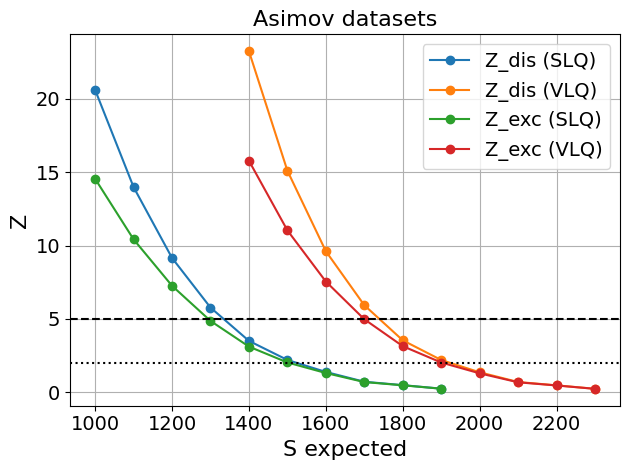

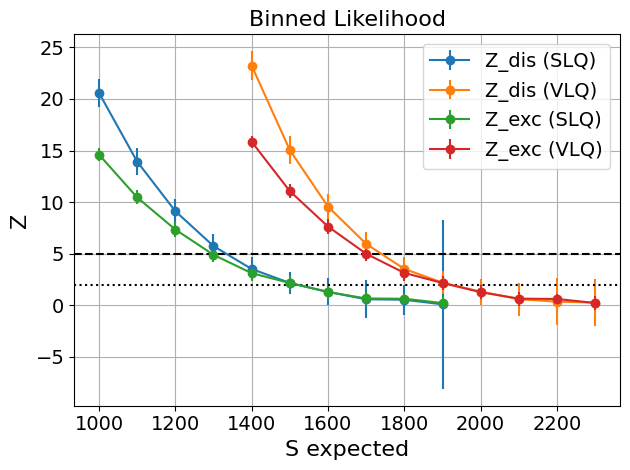

In [42]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)

#  interpolate
f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")


# find the mass such that we get Z for discovery or exclusion

m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]

m_BL_dis_SLQ = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
m_BL_exc_SLQ = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

m_BL_dis_VLQ = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1600)[0]
m_BL_exc_VLQ = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1600)[0]



print(r'm_asimov_dis_SLQ = ', m_asimov_dis_SLQ, ' GeV')
print(r'm_asimov_dis_VLQ = ', m_asimov_dis_VLQ, ' GeV')
print()
print(r'm_asimov_exc_SLQ = ', m_asimov_exc_SLQ, ' GeV')
print(r'm_asimov_exc_VLQ = ', m_asimov_exc_VLQ, ' GeV')

print()
print(r'm_BL_dis_SLQ = ', m_BL_dis_SLQ, ' GeV')
print(r'm_BL_dis_VLQ = ', m_BL_dis_VLQ, ' GeV')
print()
print(r'm_BL_exc_SLQ = ', m_BL_exc_SLQ, ' GeV')
print(r'm_BL_exc_VLQ = ', m_BL_exc_VLQ, ' GeV')





# plot ASIMOV DATASETS

plt.plot(masses_SLQ, Z_asimov_dis_SLQ, 'o-', label='Z_dis (SLQ)')
plt.plot(masses_VLQ, Z_asimov_dis_VLQ, 'o-', label='Z_dis (VLQ)')

plt.plot(masses_SLQ, Z_asimov_exc_SLQ, 'o-', label='Z_exc (SLQ)')
plt.plot(masses_VLQ, Z_asimov_exc_VLQ, 'o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.errorbar(masses_SLQ, Z_dis_SLQ, yerr=Z_dis_std_SLQ, fmt='o-', label='Z_dis (SLQ)')
plt.errorbar(masses_VLQ, Z_dis_VLQ, yerr=Z_dis_std_VLQ, fmt='o-', label='Z_dis (VLQ)')

plt.errorbar(masses_SLQ, Z_exc_SLQ, yerr=Z_exc_std_SLQ, fmt='o-', label='Z_exc (SLQ)')
plt.errorbar(masses_VLQ, Z_exc_VLQ, yerr=Z_exc_std_VLQ, fmt='o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Z-Loop for all betas

In [43]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)
Z_exc

np.float64(1.6448536269514729)

<>:227: SyntaxWarning: invalid escape sequence '\h'
<>:227: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2908/823060177.py:227: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$q(\hat{\mu})$",fontsize=16)


beta:  0.0
B_expected:  3991
S_expected_SLQ:  37.79812761135048
S_expected_VLQ:  36.51096261982728
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.81222195217751
Z_asimov_dis_VLQ =  6.5620570973607

Z_asimov_exc_SLQ =  4.924877932727605
Z_asimov_exc_VLQ =  5.441142033095752


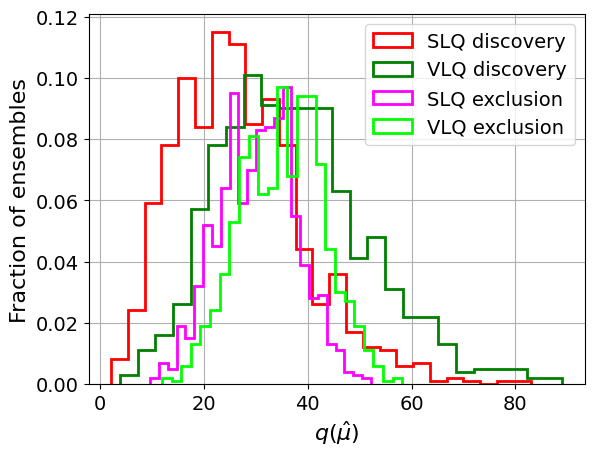


 Binned Likelihood:
Z_dis_SLQ =  5.050364345556673  +-  1.2089751648339404
Z_dis_VLQ =  5.978113990539855  +-  1.19279877046169

Z_exc_SLQ =  5.541811938842339  +-  0.6720199729833118
Z_exc_VLQ =  5.94519963853252  +-  0.6674063634841825

------------------------------------------

B_expected:  3991
S_expected_SLQ:  20.891484172663787
S_expected_VLQ:  20.863716380047777
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.7530347562879456
Z_asimov_dis_VLQ =  4.1130951449508615

Z_asimov_exc_SLQ =  3.3208514499275403
Z_asimov_exc_VLQ =  3.5990547295562143


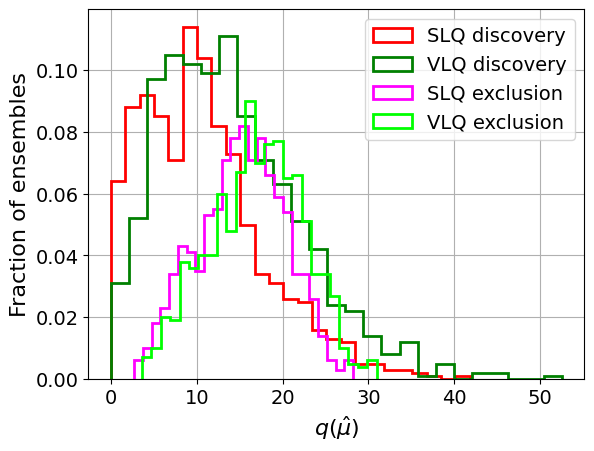


 Binned Likelihood:
Z_dis_SLQ =  3.1292542343170813  +-  1.1341412250931273
Z_dis_VLQ =  3.5764696928021102  +-  1.134947212022988

Z_exc_SLQ =  3.9178025080776693  +-  0.646415103325774
Z_exc_VLQ =  4.138918149126371  +-  0.6525644705274568

------------------------------------------

B_expected:  3991
S_expected_SLQ:  11.5469770202479
S_expected_VLQ:  11.922300316198381
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.313651978494361
Z_asimov_dis_VLQ =  2.523091579754767

Z_asimov_exc_SLQ =  2.128673716118908
Z_asimov_exc_VLQ =  2.305238884886082


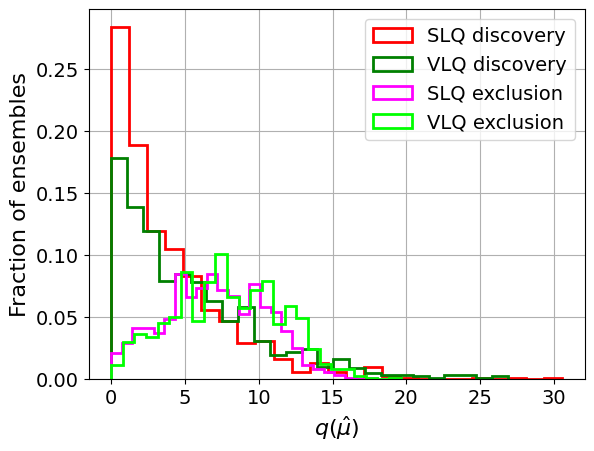


 Binned Likelihood:
Z_dis_SLQ =  1.6487527409384901  +-  1.196320673356756
Z_dis_VLQ =  1.9736429050869577  +-  1.1965740503204856

Z_exc_SLQ =  2.635048142017262  +-  0.6384576312979303
Z_exc_VLQ =  2.7684882193111062  +-  0.6544730855460819

------------------------------------------

B_expected:  3991
S_expected_SLQ:  6.382154432120097
S_expected_VLQ:  6.914590460791412
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.3786351336938911
Z_asimov_dis_VLQ =  1.5337834218654205

Z_asimov_exc_SLQ =  1.307118875697154
Z_asimov_exc_VLQ =  1.4462422646339466


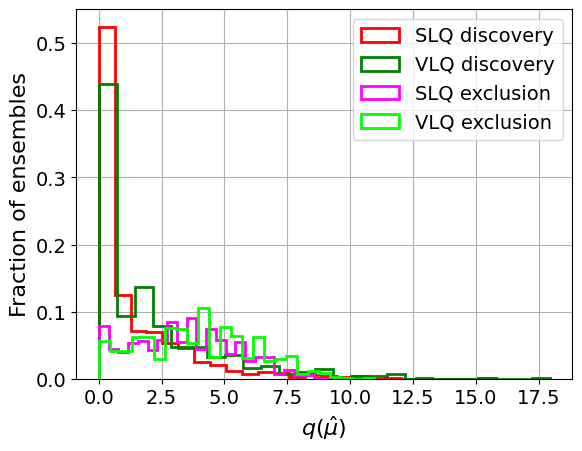


 Binned Likelihood:
Z_dis_SLQ =  0.7585480243572444  +-  1.3810361973186764
Z_dis_VLQ =  1.0435805688113808  +-  1.2219700362216042

Z_exc_SLQ =  1.842643273212489  +-  0.5515922038535538
Z_exc_VLQ =  1.9903132451756107  +-  0.5646423054225098

------------------------------------------

B_expected:  3991
S_expected_SLQ:  3.5274942631310213
S_expected_VLQ:  4.010263118058503
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.8034733242452374
Z_asimov_dis_VLQ =  0.9204936503850658

Z_asimov_exc_SLQ =  0.7777753341578705
Z_asimov_exc_VLQ =  0.8871045433170289


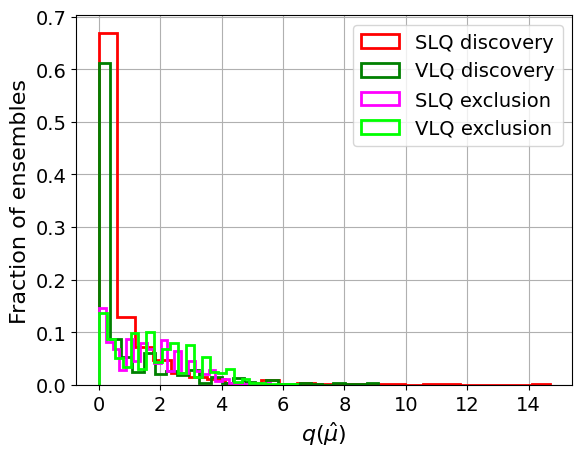


 Binned Likelihood:
Z_dis_SLQ =  0.2685484929347715  +-  2.6690335501348215
Z_dis_VLQ =  0.34872699325453826  +-  2.142904817790373

Z_exc_SLQ =  1.189164894949445  +-  0.4898175234727473
Z_exc_VLQ =  1.2979649182902366  +-  0.5138746468766626

------------------------------------------

B_expected:  3991
S_expected_SLQ:  2.034105271497075
S_expected_VLQ:  2.381597506064054
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.47981662728259994
Z_asimov_dis_VLQ =  0.5591180277759027

Z_asimov_exc_SLQ =  0.4703410880629609
Z_asimov_exc_VLQ =  0.5463509320592725


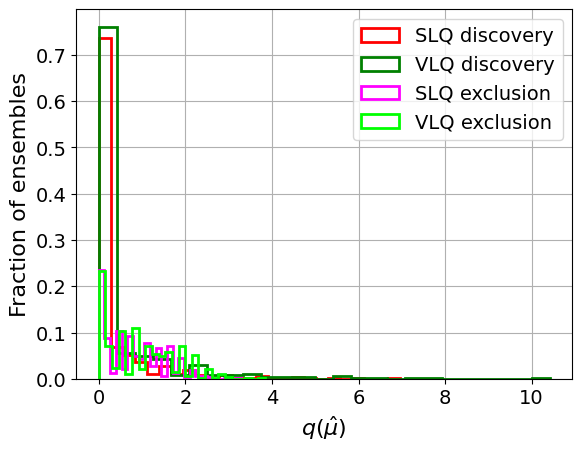

/tmp/ipykernel_2908/823060177.py:237: RuntimeWarning: divide by zero encountered in scalar divide
  Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)



 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.003736722457093596  +-  151.433093323585

Z_exc_SLQ =  0.8270204799166262  +-  0.4070497246434517
Z_exc_VLQ =  0.9128861196266221  +-  0.4321306484456355

------------------------------------------

B_expected:  3991
S_expected_SLQ:  1.1729527950697924
S_expected_VLQ:  1.4143727017185141
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.2838258035756789
Z_asimov_dis_VLQ =  0.33548810698950743

Z_asimov_exc_SLQ =  0.28043972488120444
Z_asimov_exc_VLQ =  0.3307845033500511


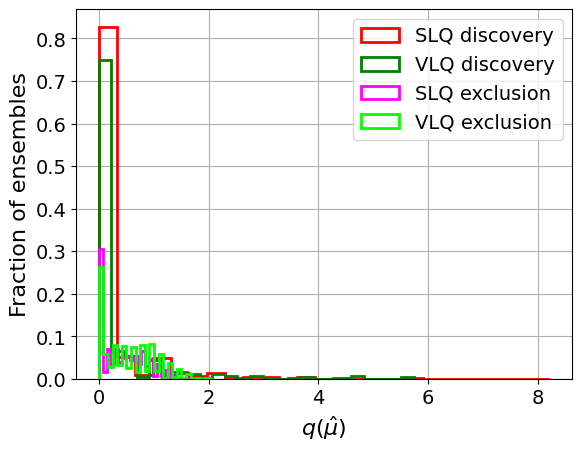

/tmp/ipykernel_2908/823060177.py:244: RuntimeWarning: divide by zero encountered in scalar divide
  Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)



 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.0  +-  inf

Z_exc_SLQ =  0.5948274606669056  +-  0.3274336159558125
Z_exc_VLQ =  0.6631402358828112  +-  0.3496366226107178

------------------------------------------

B_expected:  3991
S_expected_SLQ:  0.6725405420368572
S_expected_VLQ:  0.8565637600524608
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.16544435402927896
Z_asimov_dis_VLQ =  0.20490270833789545

Z_asimov_exc_SLQ =  0.16427891635481037
Z_asimov_exc_VLQ =  0.20312388340653184


/tmp/ipykernel_2908/823060177.py:190: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery


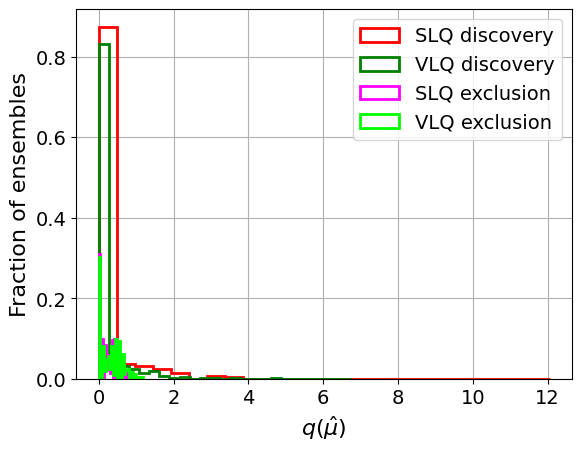


 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.0  +-  inf

Z_exc_SLQ =  0.4381466973971881  +-  0.2573133542727966
Z_exc_VLQ =  0.5029664618342867  +-  0.2796537478621676

------------------------------------------

B_expected:  3991
S_expected_SLQ:  0.385617206919496
S_expected_VLQ:  0.5187469145464527
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.09579439903093986
Z_asimov_dis_VLQ =  0.12522446488659358

Z_asimov_exc_SLQ =  0.09540066106264398
Z_asimov_exc_VLQ =  0.12455428826809864


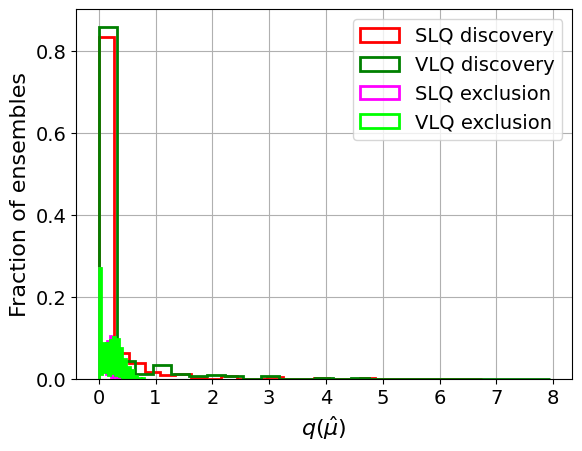


 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.0  +-  inf

Z_exc_SLQ =  0.38353618498001374  +-  0.1740122970146764
Z_exc_VLQ =  0.44358303652634823  +-  0.1979717146995026

------------------------------------------

B_expected:  3991
S_expected_SLQ:  0.2253546687600018
S_expected_VLQ:  0.3141603391380738
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.05644990809034624
Z_asimov_dis_VLQ =  0.07574987965763001

Z_asimov_exc_SLQ =  0.05631257873590145
Z_asimov_exc_VLQ =  0.0755033573742627


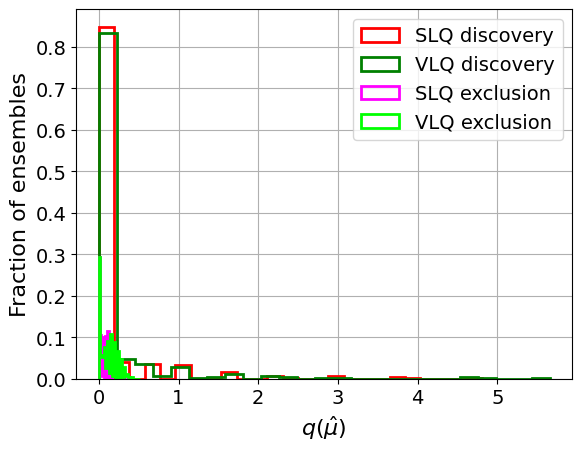


 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.0  +-  inf

Z_exc_SLQ =  0.24376888110718073  +-  0.16169748303437395
Z_exc_VLQ =  0.2938886057268042  +-  0.18124676540707602

------------------------------------------

m_asimov_dis_SLQ =  1039.4438132579119  GeV
m_asimov_dis_VLQ =  1463.7844575667498  GeV

m_asimov_exc_VLQ =  1676.8786794226  GeV
m_asimov_exc_SLQ =  1258.8907843229383  GeV

m_BL_dis_SLQ =  1002.6216272176182  GeV
m_BL_dis_VLQ =  1440.7268466633964  GeV

m_BL_exc_VLQ =  1749.8967939704912  GeV
m_BL_exc_SLQ =  1330.2672059000245  GeV

######################################

beta:  0.1
B_expected:  3991
S_expected_SLQ:  104.7285395036833
S_expected_VLQ:  101.1621483044003
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  13.432891348953337
Z_asimov_dis_VLQ =  14.91632275836491

Z_asimov_exc_SLQ =  10.152979168278868
Z_asimov_exc_VLQ =  10.93604621907599


/tmp/ipykernel_2908/823060177.py:313: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1200)[0]
/tmp/ipykernel_2908/823060177.py:317: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1500)[0]
/tmp/ipykernel_2908/823060177.py:319: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1200)[0]
/tmp/ipykernel_2908/823060177.py:322: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1500)[0]
/tmp/ipykernel_2908/823060177.py:323: RuntimeWarning

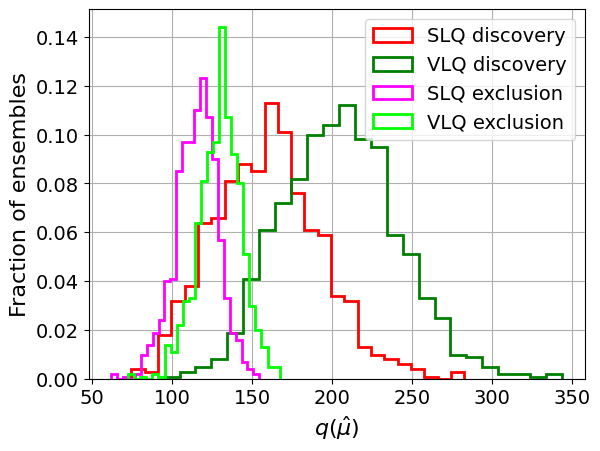


 Binned Likelihood:
Z_dis_SLQ =  12.62265185967772  +-  1.3220021615977102
Z_dis_VLQ =  14.311390533850968  +-  1.273459202763976

Z_exc_SLQ =  10.775649837759397  +-  0.6121156656523001
Z_exc_VLQ =  11.440763769095591  +-  0.5896318031429781

------------------------------------------

B_expected:  3991
S_expected_SLQ:  57.88473566638719
S_expected_VLQ:  57.80779851236154
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  8.973200649778489
Z_asimov_dis_VLQ =  9.73705090944685

Z_asimov_exc_SLQ =  7.155052876475669
Z_asimov_exc_VLQ =  7.635306036217702


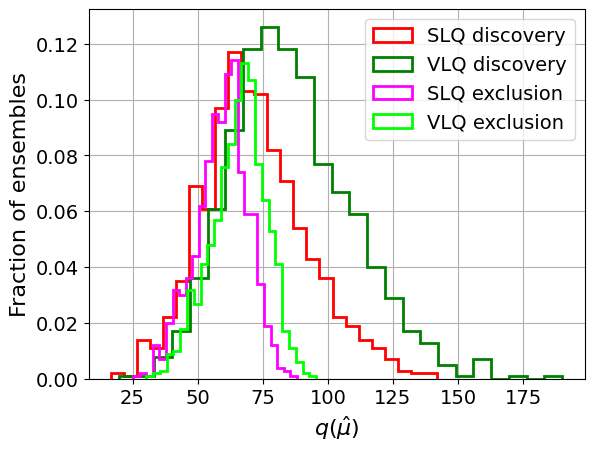


 Binned Likelihood:
Z_dis_SLQ =  8.39112085700484  +-  1.194303119153815
Z_dis_VLQ =  9.11855690246174  +-  1.2757319422874558

Z_exc_SLQ =  7.758354408957912  +-  0.6489353445988528
Z_exc_VLQ =  8.159714241263838  +-  0.6437234887385586

------------------------------------------

B_expected:  3991
S_expected_SLQ:  31.993596387827758
S_expected_VLQ:  33.03351722810766
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.738246956218019
Z_asimov_dis_VLQ =  6.212700095947953

Z_asimov_exc_SLQ =  4.84282891173665
Z_asimov_exc_VLQ =  5.1837329259268135


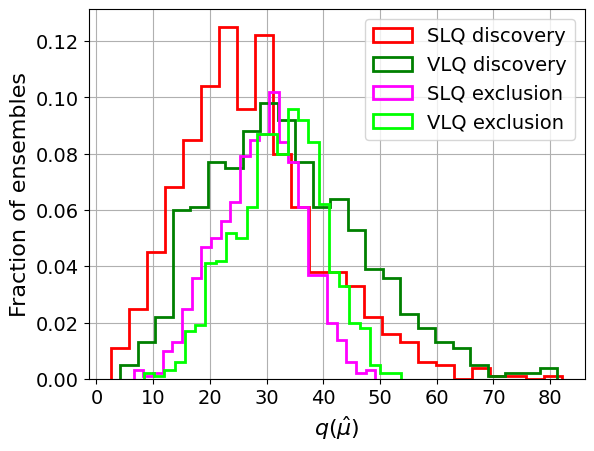


 Binned Likelihood:
Z_dis_SLQ =  5.153900777034558  +-  1.1630818237116083
Z_dis_VLQ =  5.663380409861003  +-  1.1887278184960133

Z_exc_SLQ =  5.41513231033675  +-  0.670837160343615
Z_exc_VLQ =  5.72456299548958  +-  0.6694473844232729

------------------------------------------

B_expected:  3991
S_expected_SLQ:  17.683249271907943
S_expected_VLQ:  19.15848762855986
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.535672208757834
Z_asimov_dis_VLQ =  3.907758715964863

Z_asimov_exc_SLQ =  3.140458024974935
Z_asimov_exc_VLQ =  3.436103119471566


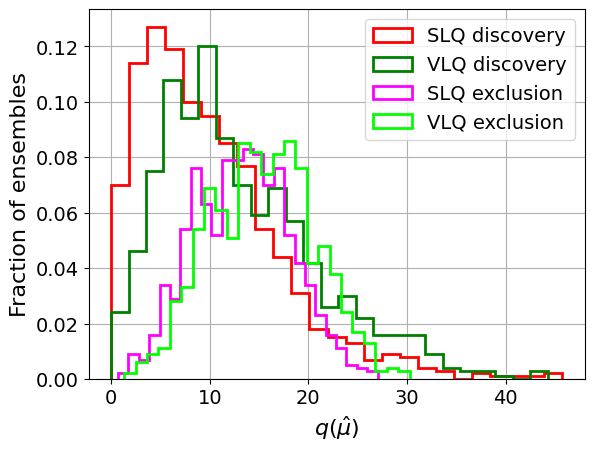


 Binned Likelihood:
Z_dis_SLQ =  2.9385487140018522  +-  1.2302715627610255
Z_dis_VLQ =  3.391876501947735  +-  1.164765232204887

Z_exc_SLQ =  3.651838517758625  +-  0.6588818147779784
Z_exc_VLQ =  3.914832458048788  +-  0.66621335727215

------------------------------------------

B_expected:  3991
S_expected_SLQ:  9.773746627978381
S_expected_VLQ:  11.11137048105088
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.1164730097459956
Z_asimov_dis_VLQ =  2.410145952022623

Z_asimov_exc_SLQ =  1.957993397567492
Z_asimov_exc_VLQ =  2.209264819469148


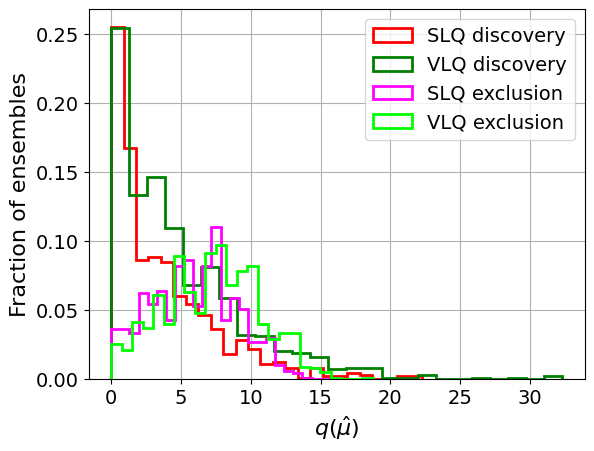


 Binned Likelihood:
Z_dis_SLQ =  1.5561120174290841  +-  1.2167292088248984
Z_dis_VLQ =  1.9312135819341132  +-  1.1947132976299313

Z_exc_SLQ =  2.4339012050172797  +-  0.6247813130265467
Z_exc_VLQ =  2.674454078676551  +-  0.6413837110069623

------------------------------------------

B_expected:  3991
S_expected_SLQ:  5.635963677117724
S_expected_VLQ:  6.598772062476544
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.2869414353565651
Z_asimov_dis_VLQ =  1.4926268290437088

Z_asimov_exc_SLQ =  1.2238688905975914
Z_asimov_exc_VLQ =  1.4093219841343387


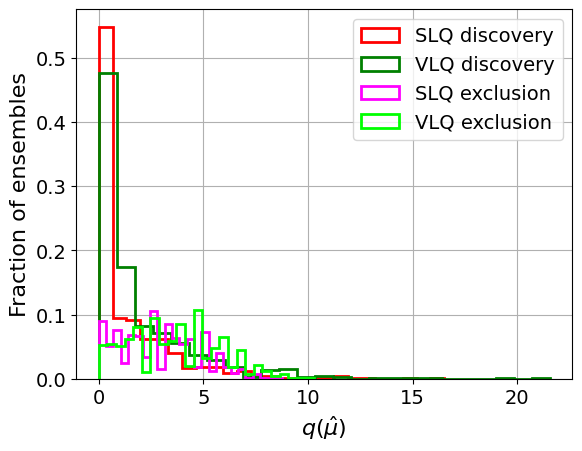


 Binned Likelihood:
Z_dis_SLQ =  0.7568113736661845  +-  1.4571234005555982
Z_dis_VLQ =  0.9976663874676284  +-  1.3187822517136014

Z_exc_SLQ =  1.6522817869011197  +-  0.5670593062752162
Z_exc_VLQ =  1.8398514159598758  +-  0.5885363150987435

------------------------------------------

B_expected:  3991
S_expected_SLQ:  3.249939637156368
S_expected_VLQ:  3.918849867060025
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.7706952816487043
Z_asimov_dis_VLQ =  0.9079256295412752

Z_asimov_exc_SLQ =  0.7469238379599957
Z_asimov_exc_VLQ =  0.8753841807279588


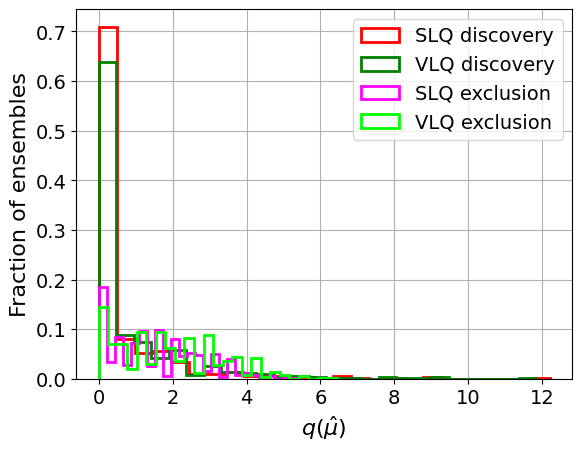


 Binned Likelihood:
Z_dis_SLQ =  0.17660906963892836  +-  3.8020799765218802
Z_dis_VLQ =  0.29888319088663606  +-  2.4426927744665963

Z_exc_SLQ =  1.1392978436468313  +-  0.5055412347494798
Z_exc_VLQ =  1.283771379474282  +-  0.5311108145868225

------------------------------------------

B_expected:  3991
S_expected_SLQ:  1.8634306293887621
S_expected_VLQ:  2.37330992964687
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.45287356642333304
Z_asimov_dis_VLQ =  0.5593558419811827

Z_asimov_exc_SLQ =  0.444397700265933
Z_asimov_exc_VLQ =  0.5465740328779495


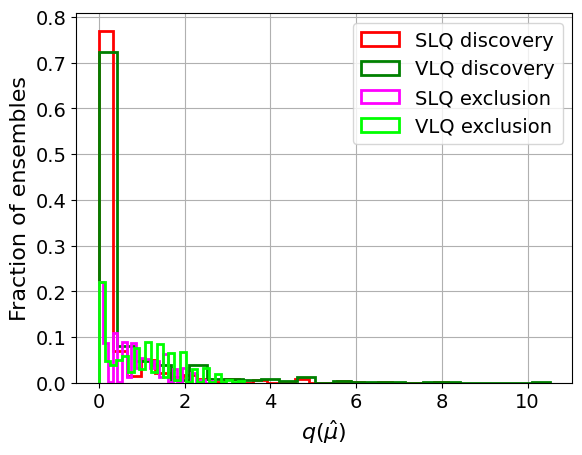


 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.024071737581242803  +-  25.398259941930814

Z_exc_SLQ =  0.7978564164362332  +-  0.40194430678472604
Z_exc_VLQ =  0.9249358256333408  +-  0.43275650605751415

------------------------------------------

B_expected:  3991
S_expected_SLQ:  1.0684425245456106
S_expected_VLQ:  1.4373094691647597
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.263527024286706
Z_asimov_dis_VLQ =  0.3437592306827893

Z_asimov_exc_SLQ =  0.2605996466352342
Z_asimov_exc_VLQ =  0.3388233709000653


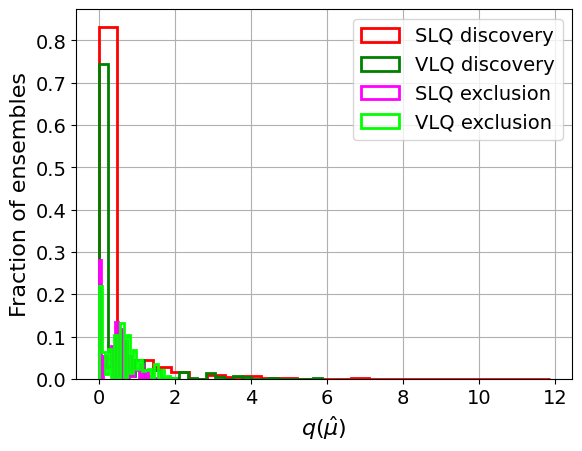


 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.0  +-  inf

Z_exc_SLQ =  0.6625676831605911  +-  0.2754626280673472
Z_exc_VLQ =  0.7729035034849006  +-  0.31128184843058226

------------------------------------------

B_expected:  3991
S_expected_SLQ:  0.6243977366350838
S_expected_VLQ:  0.870454585111042
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.15574182613514156
Z_asimov_dis_VLQ =  0.20869221550435268

Z_asimov_exc_SLQ =  0.15470753708087803
Z_asimov_exc_VLQ =  0.20684733955028062


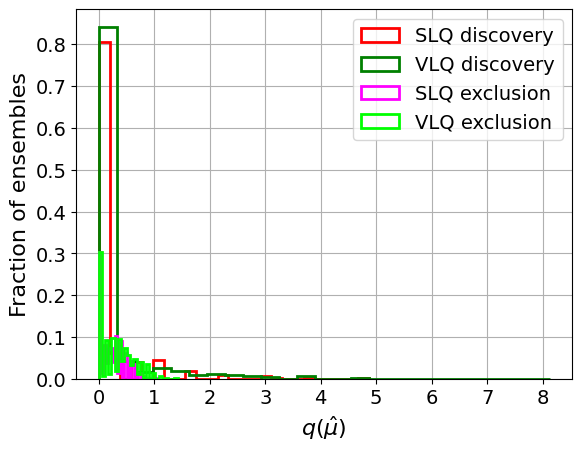


 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.0  +-  inf

Z_exc_SLQ =  0.4189091355417787  +-  0.25527653669146033
Z_exc_VLQ =  0.5077062213662851  +-  0.28505961932501567

------------------------------------------

m_asimov_dis_SLQ =  1233.517453020348  GeV
m_asimov_dis_VLQ =  1652.6130558668199  GeV

m_asimov_exc_VLQ =  1870.5564407338488  GeV
m_asimov_exc_SLQ =  1442.654858629976  GeV

m_BL_dis_SLQ =  1206.947012152275  GeV
m_BL_dis_VLQ =  1629.20445822479  GeV

m_BL_exc_VLQ =  1935.0664969454365  GeV
m_BL_exc_SLQ =  1501.4480297185373  GeV

######################################

beta:  0.3
B_expected:  3991
S_expected_SLQ:  159.21984485660903
S_expected_VLQ:  153.79782468771475
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  18.55872763293786
Z_asimov_dis_VLQ =  20.462848298507033

Z_asimov_exc_SLQ =  13.33011151124352
Z_asimov_exc_VLQ =  14.209094306712297


/tmp/ipykernel_2908/823060177.py:314: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1200)[0]
/tmp/ipykernel_2908/823060177.py:316: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1500)[0]
/tmp/ipykernel_2908/823060177.py:326: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1200)[0]


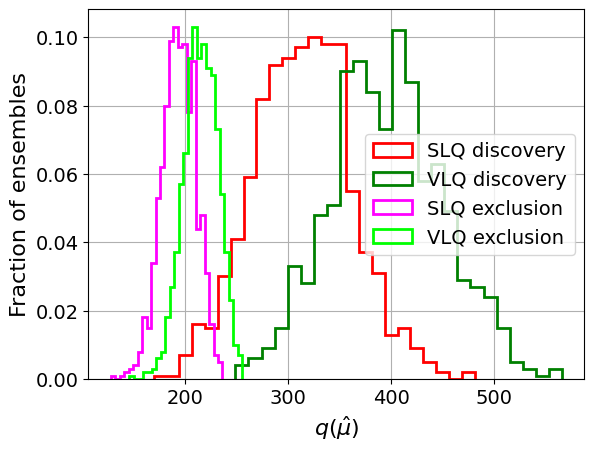


 Binned Likelihood:
Z_dis_SLQ =  17.755575309652336  +-  1.3321879504283247
Z_dis_VLQ =  19.862823852532248  +-  1.3694564036963575

Z_exc_SLQ =  13.922751099888469  +-  0.5884818826585755
Z_exc_VLQ =  14.668337965577868  +-  0.5591214326420485

------------------------------------------

B_expected:  3991
S_expected_SLQ:  88.00274190822505
S_expected_VLQ:  87.88577358434956
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  12.559199559396548
Z_asimov_dis_VLQ =  13.568088197121337

Z_asimov_exc_SLQ =  9.522985476927325
Z_asimov_exc_VLQ =  10.095860485107888


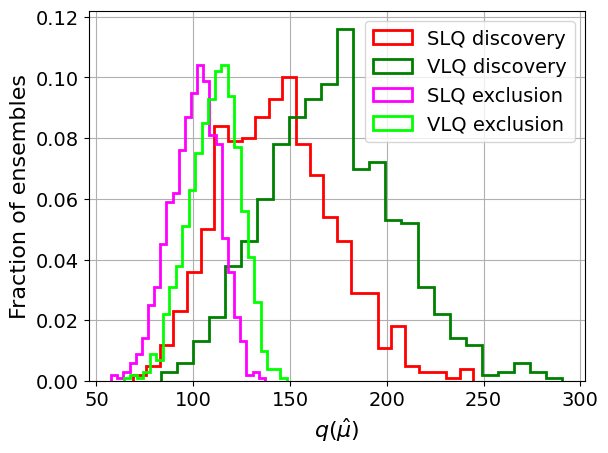


 Binned Likelihood:
Z_dis_SLQ =  11.931544524944325  +-  1.2303825262118346
Z_dis_VLQ =  13.058241317084589  +-  1.291012042857584

Z_exc_SLQ =  10.080861411315421  +-  0.6253143041856715
Z_exc_VLQ =  10.563540712191692  +-  0.6160267287898642

------------------------------------------

B_expected:  3991
S_expected_SLQ:  48.640184207818024
S_expected_VLQ:  50.22118625021448
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  8.16019653010726
Z_asimov_dis_VLQ =  8.80444209097272

Z_asimov_exc_SLQ =  6.577498065755434
Z_asimov_exc_VLQ =  7.004505403198538


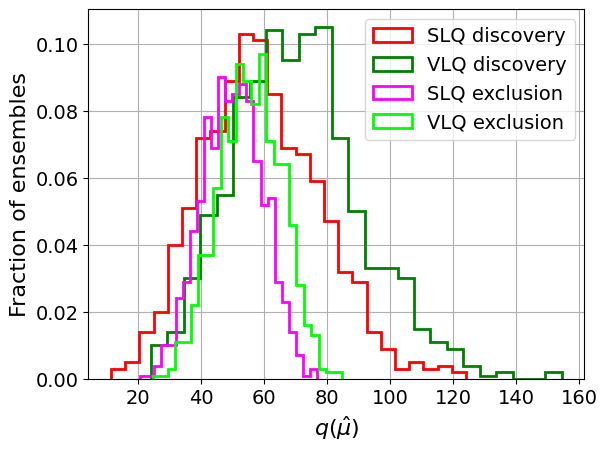


 Binned Likelihood:
Z_dis_SLQ =  7.617871222124983  +-  1.2287319575925304
Z_dis_VLQ =  8.335048401822794  +-  1.2186664215550997

Z_exc_SLQ =  7.076074363860548  +-  0.6688496329675384
Z_exc_VLQ =  7.454808235605317  +-  0.663881767937629

------------------------------------------

B_expected:  3991
S_expected_SLQ:  26.884020525607593
S_expected_VLQ:  29.12684013701233
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.11199303040695
Z_asimov_dis_VLQ =  5.630339784396209

Z_asimov_exc_SLQ =  4.369280699612981
Z_asimov_exc_VLQ =  4.754885896455437


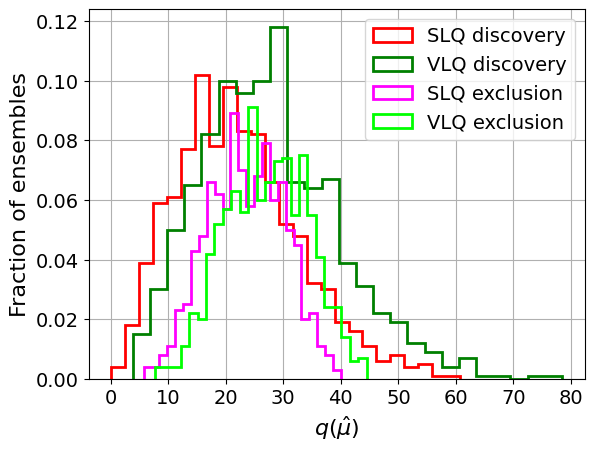


 Binned Likelihood:
Z_dis_SLQ =  4.563549455742746  +-  1.1576679128030702
Z_dis_VLQ =  5.165675357010513  +-  1.1478894778949442

Z_exc_SLQ =  4.838260761906876  +-  0.6809212832426641
Z_exc_VLQ =  5.198498907987328  +-  0.6815248614077362

------------------------------------------

B_expected:  3991
S_expected_SLQ:  14.859124639275555
S_expected_VLQ:  16.892727546105093
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.1065503317485295
Z_asimov_dis_VLQ =  3.524972577034675

Z_asimov_exc_SLQ =  2.7908185348801804
Z_asimov_exc_VLQ =  3.130279713127657


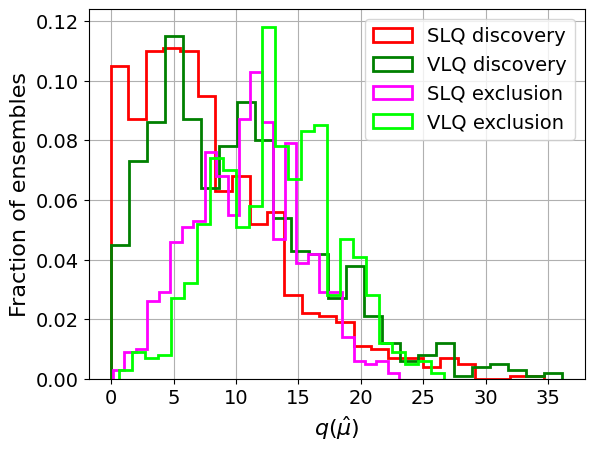


 Binned Likelihood:
Z_dis_SLQ =  2.5878451749906843  +-  1.159398692461929
Z_dis_VLQ =  3.0249574604607585  +-  1.092856009200079

Z_exc_SLQ =  3.277708019176475  +-  0.6462955883816986
Z_exc_VLQ =  3.6024184147064764  +-  0.6546658741346149

------------------------------------------

B_expected:  3991
S_expected_SLQ:  8.568411882193848
S_expected_VLQ:  10.032179089012217
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.9105699322240823
Z_asimov_dis_VLQ =  2.2091547884476626

Z_asimov_exc_SLQ =  1.7789936511218332
Z_asimov_exc_VLQ =  2.037533035413457


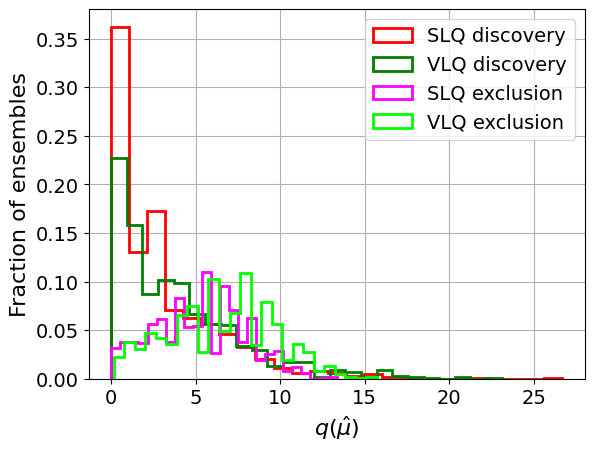


 Binned Likelihood:
Z_dis_SLQ =  1.4687186239886916  +-  1.1199346209023668
Z_dis_VLQ =  1.7086132158526035  +-  1.1002371172705157

Z_exc_SLQ =  2.3378824269888883  +-  0.5782790808992024
Z_exc_VLQ =  2.6015754575699086  +-  0.5948528855846534

------------------------------------------

B_expected:  3991
S_expected_SLQ:  4.940915697608696
S_expected_VLQ:  5.957866602614997
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.1538589761015285
Z_asimov_dis_VLQ =  1.356107991752441

Z_asimov_exc_SLQ =  1.102482547813503
Z_asimov_exc_VLQ =  1.2864789108726737


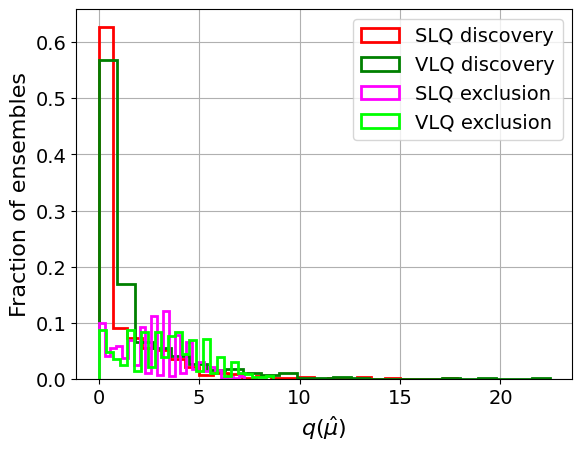


 Binned Likelihood:
Z_dis_SLQ =  0.5411450820810677  +-  1.8503884721011106
Z_dis_VLQ =  0.7593785763293084  +-  1.5842789825078845

Z_exc_SLQ =  1.6475953091601716  +-  0.5065542257821899
Z_exc_VLQ =  1.8429108801754748  +-  0.5329582698815071

------------------------------------------

B_expected:  3991
S_expected_SLQ:  2.8329922017283287
S_expected_VLQ:  3.608166795658737
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.6820189864263143
Z_asimov_dis_VLQ =  0.8406763088666194

Z_asimov_exc_SLQ =  0.6632320156195965
Z_asimov_exc_VLQ =  0.8125931043846926


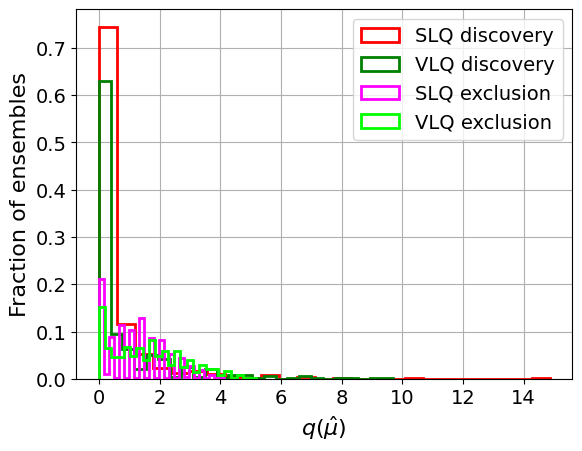


 Binned Likelihood:
Z_dis_SLQ =  0.04743485026293673  +-  12.948672045917654
Z_dis_VLQ =  0.28665031745806097  +-  2.466986680295779

Z_exc_SLQ =  1.0362102240189504  +-  0.4704983094074159
Z_exc_VLQ =  1.2073139560431998  +-  0.5023099383221363

------------------------------------------

B_expected:  3991
S_expected_SLQ:  1.624363843920241
S_expected_VLQ:  2.185155944844428
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.39837213260715015
Z_asimov_dis_VLQ =  0.5188135120952623

Z_asimov_exc_SLQ =  0.3917750967712987
Z_asimov_exc_VLQ =  0.5077697249753428


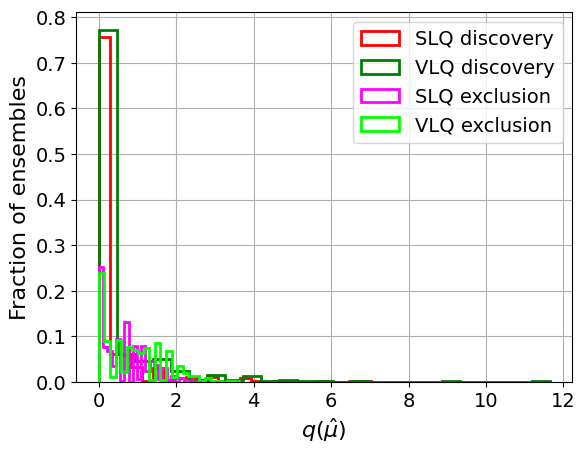


 Binned Likelihood:
Z_dis_SLQ =  0.0  +-  inf
Z_dis_VLQ =  0.0  +-  inf

Z_exc_SLQ =  0.7285250411534616  +-  0.39221749170489256
Z_exc_VLQ =  0.8731114051124363  +-  0.43119853216163834

------------------------------------------

B_expected:  3991
S_expected_SLQ:  0.9492781168055858
S_expected_VLQ:  1.323360801677462
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.23596731540797097
Z_asimov_dis_VLQ =  0.31584022212071844

Z_asimov_exc_SLQ =  0.23361301449787647
Z_asimov_exc_VLQ =  0.3116616574252513


In [ ]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_136TeV = []
m_asimov_exc_SLQ_136TeV = []

m_asimov_dis_VLQ_136TeV = []
m_asimov_exc_VLQ_136TeV = []


m_BL_dis_SLQ_136TeV = []
m_BL_exc_SLQ_136TeV = []

m_BL_dis_VLQ_136TeV = []
m_BL_exc_VLQ_136TeV = []


m_BL_dis_SLQ_low_136TeV = []
m_BL_exc_SLQ_low_136TeV = []

m_BL_dis_VLQ_low_136TeV = []
m_BL_exc_VLQ_low_136TeV = []


m_BL_dis_SLQ_high_136TeV = []
m_BL_exc_SLQ_high_136TeV = []

m_BL_dis_VLQ_high_136TeV = []
m_BL_exc_VLQ_high_136TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_136TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_136TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1200)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1200)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1500)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1500)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_136TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_136TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_136TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_136TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_136TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_136TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_136TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_136TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_136TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_136TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_136TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_136TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_136TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_136TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_136TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_136TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


In [ ]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

# SAVE

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_136TeV,
    m_asimov_dis_SLQ_136TeV,
    m_asimov_exc_VLQ_136TeV,
    m_asimov_dis_VLQ_136TeV,
    m_BL_exc_SLQ_136TeV,
    m_BL_dis_SLQ_136TeV,
    m_BL_exc_VLQ_136TeV,
    m_BL_dis_VLQ_136TeV,
    m_BL_exc_SLQ_low_136TeV,
    m_BL_dis_SLQ_low_136TeV,
    m_BL_exc_VLQ_low_136TeV,
    m_BL_dis_VLQ_low_136TeV,
    m_BL_exc_SLQ_high_136TeV,
    m_BL_dis_SLQ_high_136TeV,
    m_BL_exc_VLQ_high_136TeV,
    m_BL_dis_VLQ_high_136TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_136TeV m_asimov_dis_SLQ_136TeV m_asimov_exc_VLQ_136TeV m_asimov_dis_VLQ_136TeV m_BL_exc_SLQ_136TeV m_BL_dis_SLQ_136TeV m_BL_exc_VLQ_136TeV m_BL_dis_VLQ_136TeV m_BL_exc_SLQ_low_136TeV m_BL_dis_SLQ_low_136TeV m_BL_exc_VLQ_low_136TeV m_BL_dis_VLQ_low_136TeV m_BL_exc_SLQ_high_136TeV m_BL_dis_SLQ_high_136TeV m_BL_exc_VLQ_high_136TeV m_BL_dis_VLQ_high_136TeV',
           comments='')

print(f"Data saved to: {file_path}")


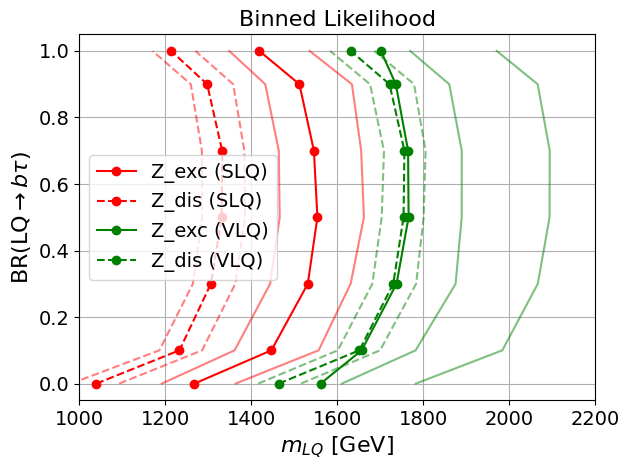

In [54]:

# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV_ = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV = loaded_data[:, 16]




# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_136TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_136TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_136TeV, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_136TeV, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_136TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_136TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_136TeV, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_136TeV, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### down

In [44]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_136TeV = []
m_asimov_exc_SLQ_136TeV = []

m_asimov_dis_VLQ_136TeV = []
m_asimov_exc_VLQ_136TeV = []


m_BL_dis_SLQ_136TeV = []
m_BL_exc_SLQ_136TeV = []

m_BL_dis_VLQ_136TeV = []
m_BL_exc_VLQ_136TeV = []


m_BL_dis_SLQ_low_136TeV = []
m_BL_exc_SLQ_low_136TeV = []

m_BL_dis_VLQ_low_136TeV = []
m_BL_exc_VLQ_low_136TeV = []


m_BL_dis_SLQ_high_136TeV = []
m_BL_exc_SLQ_high_136TeV = []

m_BL_dis_VLQ_high_136TeV = []
m_BL_exc_VLQ_high_136TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_136TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_136TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM_down, scoresA_SLQ_down[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM_down, scoresA_VLQ_down[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM_down, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1200)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1200)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1500)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1500)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_136TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_136TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_136TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_136TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_136TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_136TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_136TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_136TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_136TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_136TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_136TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_136TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_136TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_136TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_136TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_136TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

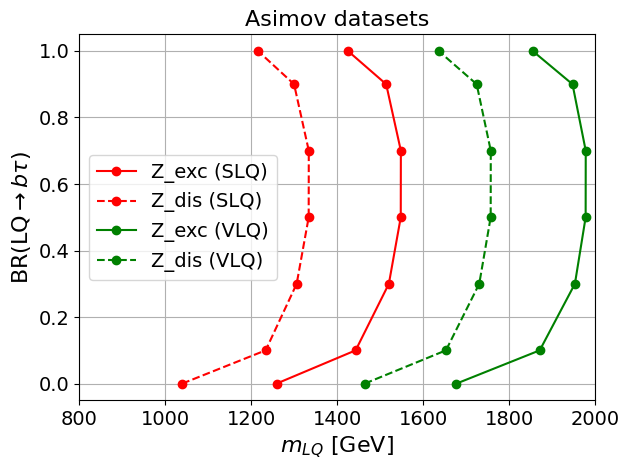

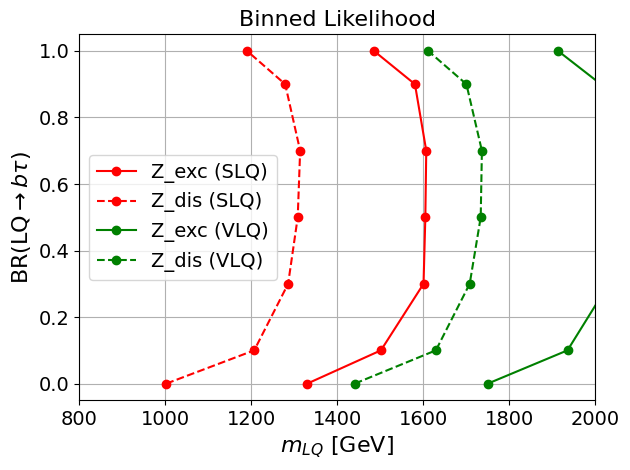

In [45]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [46]:

# SAVE

file_path = mainfolder + 'saved-results/Z136TeV_err_down.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_136TeV,
    m_asimov_dis_SLQ_136TeV,
    m_asimov_exc_VLQ_136TeV,
    m_asimov_dis_VLQ_136TeV,
    m_BL_exc_SLQ_136TeV,
    m_BL_dis_SLQ_136TeV,
    m_BL_exc_VLQ_136TeV,
    m_BL_dis_VLQ_136TeV,
    m_BL_exc_SLQ_low_136TeV,
    m_BL_dis_SLQ_low_136TeV,
    m_BL_exc_VLQ_low_136TeV,
    m_BL_dis_VLQ_low_136TeV,
    m_BL_exc_SLQ_high_136TeV,
    m_BL_dis_SLQ_high_136TeV,
    m_BL_exc_VLQ_high_136TeV,
    m_BL_dis_VLQ_high_136TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_136TeV m_asimov_dis_SLQ_136TeV m_asimov_exc_VLQ_136TeV m_asimov_dis_VLQ_136TeV m_BL_exc_SLQ_136TeV m_BL_dis_SLQ_136TeV m_BL_exc_VLQ_136TeV m_BL_dis_VLQ_136TeV m_BL_exc_SLQ_low_136TeV m_BL_dis_SLQ_low_136TeV m_BL_exc_VLQ_low_136TeV m_BL_dis_VLQ_low_136TeV m_BL_exc_SLQ_high_136TeV m_BL_dis_SLQ_high_136TeV m_BL_exc_VLQ_high_136TeV m_BL_dis_VLQ_high_136TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z136TeV_err_down.txt


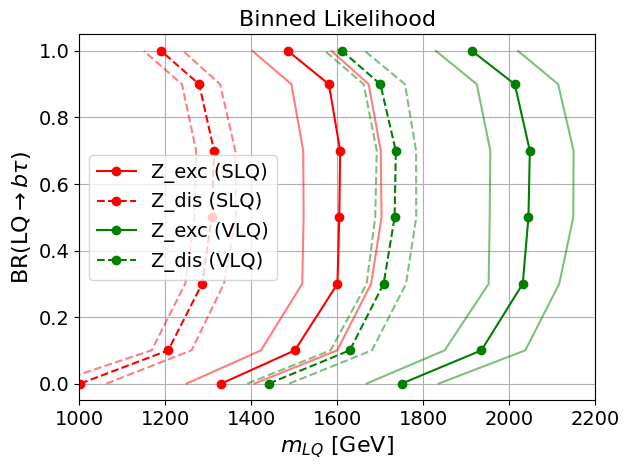

In [47]:

# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err_down.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV_down = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV_down = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV_down = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV_down = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV_down = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV_down = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV_down = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV_down = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV_down = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV_down = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV_down = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV_down = loaded_data[:, 16]




# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_136TeV_down, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_136TeV_down, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_136TeV_down, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_136TeV_down, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_136TeV_down, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_136TeV_down, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_136TeV_down, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_136TeV_down, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_136TeV_down, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_136TeV_down, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_136TeV_down, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_136TeV_down, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### up

In [48]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_136TeV = []
m_asimov_exc_SLQ_136TeV = []

m_asimov_dis_VLQ_136TeV = []
m_asimov_exc_VLQ_136TeV = []


m_BL_dis_SLQ_136TeV = []
m_BL_exc_SLQ_136TeV = []

m_BL_dis_VLQ_136TeV = []
m_BL_exc_VLQ_136TeV = []


m_BL_dis_SLQ_low_136TeV = []
m_BL_exc_SLQ_low_136TeV = []

m_BL_dis_VLQ_low_136TeV = []
m_BL_exc_VLQ_low_136TeV = []


m_BL_dis_SLQ_high_136TeV = []
m_BL_exc_SLQ_high_136TeV = []

m_BL_dis_VLQ_high_136TeV = []
m_BL_exc_VLQ_high_136TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_136TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_136TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM_up, scoresA_SLQ_up[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM_up, scoresA_VLQ_up[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM_up, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1200)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1200)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1500)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1500)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1200)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1200)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1500)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1500)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_136TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_136TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_136TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_136TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_136TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_136TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_136TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_136TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_136TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_136TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_136TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_136TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_136TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_136TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_136TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_136TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

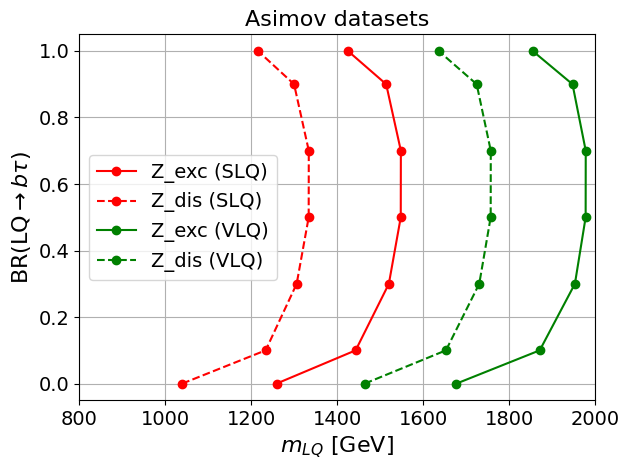

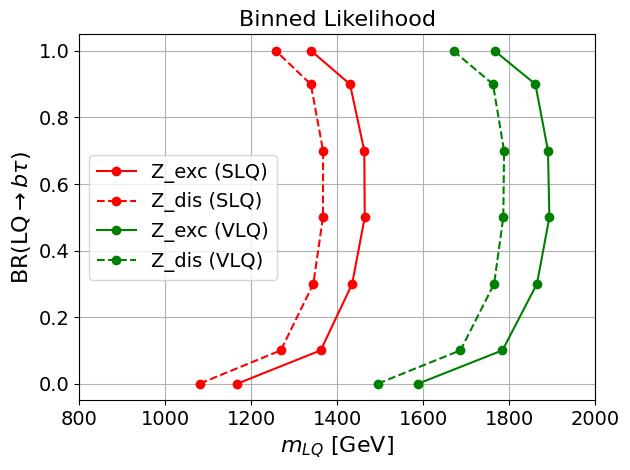

In [49]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [50]:

# SAVE

file_path = mainfolder + 'saved-results/Z136TeV_err_up.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_136TeV,
    m_asimov_dis_SLQ_136TeV,
    m_asimov_exc_VLQ_136TeV,
    m_asimov_dis_VLQ_136TeV,
    m_BL_exc_SLQ_136TeV,
    m_BL_dis_SLQ_136TeV,
    m_BL_exc_VLQ_136TeV,
    m_BL_dis_VLQ_136TeV,
    m_BL_exc_SLQ_low_136TeV,
    m_BL_dis_SLQ_low_136TeV,
    m_BL_exc_VLQ_low_136TeV,
    m_BL_dis_VLQ_low_136TeV,
    m_BL_exc_SLQ_high_136TeV,
    m_BL_dis_SLQ_high_136TeV,
    m_BL_exc_VLQ_high_136TeV,
    m_BL_dis_VLQ_high_136TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_136TeV m_asimov_dis_SLQ_136TeV m_asimov_exc_VLQ_136TeV m_asimov_dis_VLQ_136TeV m_BL_exc_SLQ_136TeV m_BL_dis_SLQ_136TeV m_BL_exc_VLQ_136TeV m_BL_dis_VLQ_136TeV m_BL_exc_SLQ_low_136TeV m_BL_dis_SLQ_low_136TeV m_BL_exc_VLQ_low_136TeV m_BL_dis_VLQ_low_136TeV m_BL_exc_SLQ_high_136TeV m_BL_dis_SLQ_high_136TeV m_BL_exc_VLQ_high_136TeV m_BL_dis_VLQ_high_136TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z136TeV_err_up.txt


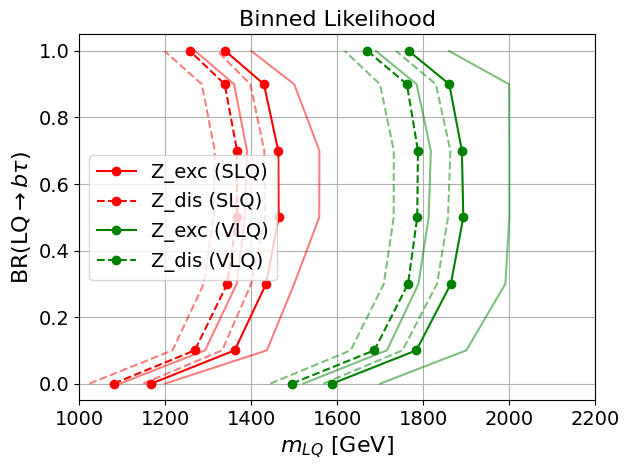

In [51]:

# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err_up.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV_up = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV_up = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV_up = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV_up = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV_up = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV_up = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV_up = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV_up = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV_up = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV_up = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV_up = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV_up = loaded_data[:, 16]




# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_136TeV_up, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_136TeV_up, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_136TeV_up, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_136TeV_up, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_136TeV_up, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_136TeV_up, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_136TeV_up, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_136TeV_up, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_136TeV_up, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_136TeV_up, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_136TeV_up, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_136TeV_up, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### no sistematics

In [55]:
# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV = loaded_data[:, 16]

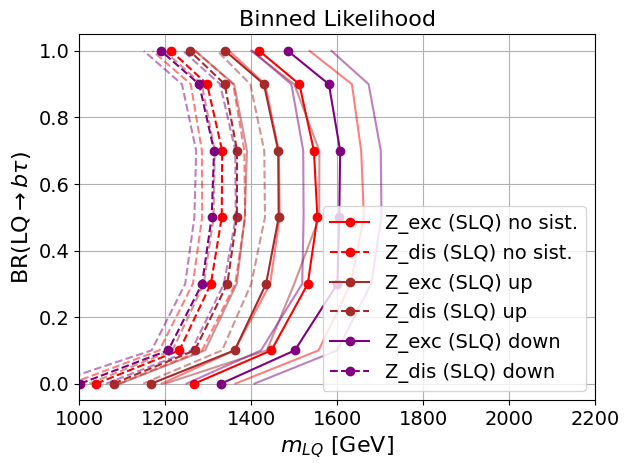

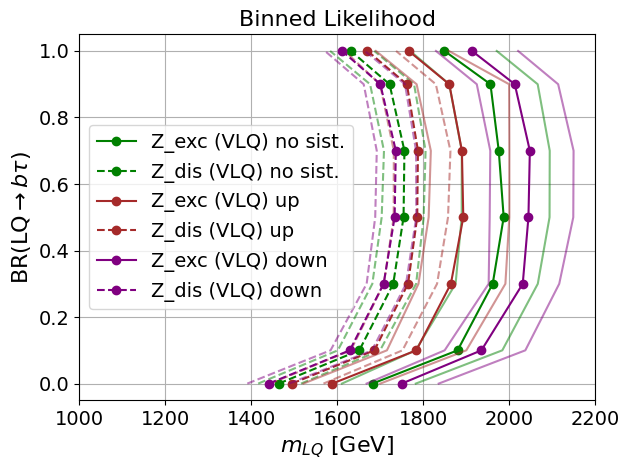

In [56]:
plt.plot(m_BL_exc_SLQ_136TeV, betas, 'o-', c='red', label='Z_exc (SLQ) no sist.')
plt.plot(m_BL_exc_SLQ_low_136TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_136TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_136TeV, betas, 'o--', c='red', label='Z_dis (SLQ) no sist.')
plt.plot(m_BL_dis_SLQ_low_136TeV, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_136TeV, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_SLQ_136TeV_up, betas, 'o-', c='brown', label='Z_exc (SLQ) up')
plt.plot(m_BL_exc_SLQ_low_136TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_136TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_dis_SLQ_136TeV_up, betas, 'o--', c='brown', label='Z_dis (SLQ) up')
plt.plot(m_BL_dis_SLQ_low_136TeV_up, betas, '--', c='brown', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_136TeV_up, betas, '--', c='brown', alpha=0.5)

plt.plot(m_BL_exc_SLQ_136TeV_down, betas, 'o-', c='purple', label='Z_exc (SLQ) down')
plt.plot(m_BL_exc_SLQ_low_136TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_136TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_dis_SLQ_136TeV_down, betas, 'o--', c='purple', label='Z_dis (SLQ) down')
plt.plot(m_BL_dis_SLQ_low_136TeV_down, betas, '--', c='purple', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_136TeV_down, betas, '--', c='purple', alpha=0.5)



# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



plt.plot(m_BL_exc_VLQ_136TeV, betas, 'o-', c='green', label='Z_exc (VLQ) no sist.')
plt.plot(m_BL_exc_VLQ_low_136TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_136TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_136TeV, betas, 'o--', c='green', label='Z_dis (VLQ) no sist.')
plt.plot(m_BL_dis_VLQ_low_136TeV, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_136TeV, betas, '--', c='green', alpha=0.5)

plt.plot(m_BL_exc_VLQ_136TeV_up, betas, 'o-', c='brown', label='Z_exc (VLQ) up')
plt.plot(m_BL_exc_VLQ_low_136TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_136TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_dis_VLQ_136TeV_up, betas, 'o--', c='brown', label='Z_dis (VLQ) up')
plt.plot(m_BL_dis_VLQ_low_136TeV_up, betas, '--', c='brown', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_136TeV_up, betas, '--', c='brown', alpha=0.5)

plt.plot(m_BL_exc_VLQ_136TeV_down, betas, 'o-', c='purple', label='Z_exc (VLQ) down')
plt.plot(m_BL_exc_VLQ_low_136TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_136TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_dis_VLQ_136TeV_down, betas, 'o--', c='purple', label='Z_dis (VLQ) down')
plt.plot(m_BL_dis_VLQ_low_136TeV_down, betas, '--', c='purple', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_136TeV_down, betas, '--', c='purple', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()